In [1]:
# CELL 1 — Imports + progress

import json
import random
from pathlib import Path

import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt
from tqdm import tqdm  # text tqdm, no ipywidgets needed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)

# PROOF: tqdm should move
for _ in tqdm(range(30), desc="PROOF tqdm", leave=True):
    pass

print("OK — Imports loaded and tqdm works.")


PROOF tqdm: 100%|██████████| 30/30 [00:00<?, ?it/s]

OK — Imports loaded and tqdm works.


In [2]:
# CELL 1.2 — Fix DEVICE type + PROOF
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROOF — DEVICE:", DEVICE, "| type:", type(DEVICE))


PROOF — DEVICE: cuda | type: <class 'torch.device'>


In [3]:
# CELL 2 — REPLACE: Paths + device/CUDA proof (NO fake paths)

from pathlib import Path
import torch

# --- USER CONFIRMED PATHS (do not change) ---
BASE_DIR: Path = Path(r"F:\Bracu\THESIS\Final Defence\Dataset\code")
CSV_FILE: str = "dmsa dataset.csv"
JSON_FILE: str = "dmsa.json"

print("PROOF — BASE_DIR:", BASE_DIR)
print("PROOF — CSV_FILE:", CSV_FILE)
print("PROOF — JSON_FILE:", JSON_FILE)
print("PROOF — BASE_DIR exists:", BASE_DIR.exists())
print("PROOF — CSV exists:", (BASE_DIR / CSV_FILE).exists())
print("PROOF — JSON exists:", (BASE_DIR / JSON_FILE).exists())

# --- DEVICE / CUDA PROOF ---
print("\n--- DEVICE PROOF ---")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected DEVICE:", DEVICE)

if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print(f"GPU total memory: {props.total_memory/1024**3:.2f} GB")
# --- Derived absolute paths (used by later cells) ---
CSV_PATH: Path = BASE_DIR / CSV_FILE
JSON_PATH: Path = BASE_DIR / JSON_FILE

print("\nPROOF — CSV_PATH:", CSV_PATH)
print("PROOF — JSON_PATH:", JSON_PATH)


PROOF — BASE_DIR: F:\Bracu\THESIS\Final Defence\Dataset\code
PROOF — CSV_FILE: dmsa dataset.csv
PROOF — JSON_FILE: dmsa.json
PROOF — BASE_DIR exists: True
PROOF — CSV exists: True
PROOF — JSON exists: True

--- DEVICE PROOF ---
Torch: 2.5.1+cu121
CUDA available: True
Selected DEVICE: cuda
GPU: NVIDIA GeForce GTX 1660 Ti
GPU total memory: 6.00 GB

PROOF — CSV_PATH: F:\Bracu\THESIS\Final Defence\Dataset\code\dmsa dataset.csv
PROOF — JSON_PATH: F:\Bracu\THESIS\Final Defence\Dataset\code\dmsa.json


In [4]:
# CELL 3 — Load CSV + PROOF

df = pd.read_csv(CSV_PATH)

print("PROOF — rows:", len(df))
print("PROOF — cols:", len(df.columns))
print("\nPROOF — column names:")
print(list(df.columns))

display(df.head(5))


PROOF — rows: 2294
PROOF — cols: 23

PROOF — column names:
['PATIENT NAME', 'AGE', 'AGE in MONTHS', 'SEX', 'LINK', 'VIEW', 'SIZE LEFT', 'SIZE RIGHT', 'ANATOMY', 'SHAPE LEFT', 'SHAPE RIGHT', 'POSITION', 'ECTOPIC POSITION LEFT', 'ECTOPIC POSITION RIGHT', 'Kidney COUNT', 'SCAR', 'SCAR LEFT', 'SCAR RIGHT', 'HDN', 'CORTICAL UPTAKE LEFT', 'CORTICAL UPTAKE RIGHT', 'Comment', 'CH']


,PATIENT NAME,AGE,AGE in MONTHS,SEX,LINK,VIEW,SIZE LEFT,SIZE RIGHT,ANATOMY,SHAPE LEFT,...,ECTOPIC POSITION RIGHT,Kidney COUNT,SCAR,SCAR LEFT,SCAR RIGHT,HDN,CORTICAL UPTAKE LEFT,CORTICAL UPTAKE RIGHT,Comment,CH
0,A RAHMAN,6M,6.0,M,Data\A_RAHMAN_6_MONTHS.jpeg,P,NORMAL,NORMAL,NORMAL,NORMAL,...,NOT APPLICABLE,2,YES,NOT APPLICABLE,MULTIPLE,NOT APPLICABLE,NORMAL,REDUCED,NaN,-
1,A RAHMAN,6M,6.0,M,Data\A_RAHMAN_6_MONTHS_1.jpeg,LPO,NORMAL,NORMAL,NORMAL,NORMAL,...,NOT APPLICABLE,2,YES,NOT APPLICABLE,MULTIPLE,NOT APPLICABLE,NORMAL,REDUCED,NaN,-
2,A RAHMAN,6M,6.0,M,Data\A_RAHMAN_6_MONTHS_2.jpeg,RPO,NORMAL,NORMAL,NORMAL,NORMAL,...,NOT APPLICABLE,2,YES,NOT APPLICABLE,MULTIPLE,NOT APPLICABLE,NORMAL,REDUCED,NaN,-
3,ABDUL ALIM,1M,1.0,M,Data\ABDUL_ALIM_1_MONTHS.jpeg,P,NORMAL,BIGGER,NORMAL,NORMAL,...,NOT APPLICABLE,2,NO,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NORMAL,REDUCED,NaN,-
4,ABDUL ALIM,1M,1.0,M,Data\ABDUL_ALIM_1_MONTHS_1.jpeg,LPO,NORMAL,BIGGER,NORMAL,NORMAL,...,NOT APPLICABLE,2,NO,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NORMAL,REDUCED,NaN,-


In [5]:
# CELL 4 — LOCK columns explicitly from your CSV + PROOF (NO searching)

COL_PATIENT = "PATIENT NAME"
COL_LINK    = "LINK"
COL_VIEW    = "VIEW"

COL_UPTAKE_L = "CORTICAL UPTAKE LEFT"
COL_UPTAKE_R = "CORTICAL UPTAKE RIGHT"

COL_ANATOMY  = "ANATOMY"
COL_POSITION = "POSITION"

# (optional, later heads)
COL_SIZE_L = "SIZE LEFT"
COL_SIZE_R = "SIZE RIGHT"
COL_SCAR_L = "SCAR LEFT"
COL_SCAR_R = "SCAR RIGHT"

# PROOF: assert every column exists
must = [
    COL_PATIENT, COL_LINK, COL_VIEW,
    COL_UPTAKE_L, COL_UPTAKE_R,
    COL_ANATOMY, COL_POSITION,
    COL_SIZE_L, COL_SIZE_R, COL_SCAR_L, COL_SCAR_R
]
missing = [c for c in must if c not in df.columns]
print("PROOF — missing columns:", missing)
assert len(missing) == 0, f"Missing columns in CSV: {missing}"

print("OK — Column locking succeeded.")
print("PROOF — Uptake columns:", COL_UPTAKE_L, "|", COL_UPTAKE_R)


PROOF — missing columns: []
OK — Column locking succeeded.
PROOF — Uptake columns: CORTICAL UPTAKE LEFT | CORTICAL UPTAKE RIGHT


In [6]:
# CELL 5 — Drop corrupted rows by LINK (exact paths) + PROOF

BAD_LINKS = {
    r"Data\MITHALI_3_MONTHS.jpeg",
    r"Data\MITHALI_3_MONTHS_1.jpeg",
    r"Data\MITHALI_3_MONTHS_2.jpeg",

    r"Data\HUZAIFA_38DAYS.jpeg",
    r"Data\HUZAIFA_38DAYS_1.jpeg",
    r"Data\HUZAIFA_38DAYS_2.jpeg",

    r"Data\HASAN_AHMMED_PATOARI_72_YRS.jpeg",
    r"Data\HASAN_AHMMED_PATOARI_72_YRS_1.jpeg",
    r"Data\HASAN_AHMMED_PATOARI_72_YRS_2.jpeg",

    r"Data\FATEMATUZ_JOHRA_042YRS.jpeg",
    r"Data\FATEMATUZ_JOHRA_042YRS_1.jpeg",
    r"Data\FATEMATUZ_JOHRA_042YRS_2.jpeg",
    r"Data\FATEMATUZ_JOHRA_42YRS.jpeg",
    r"Data\FATEMATUZ_JOHRA_42YRS_1.jpeg",
    r"Data\FATEMATUZ_JOHRA_42YRS_2.jpeg",

    r"Data\AFNAN_5YRS.jpeg",
    r"Data\AFNAN_5YRS_1.jpeg",
    r"Data\AFNAN_5YRS_2.jpeg",
}

def norm_link(x):
    # normalize slashes so "Data/..." and "Data\..." match
    s = str(x).strip()
    s = s.replace("/", "\\")
    return s

before = len(df)

link_norm = df[COL_LINK].apply(norm_link)
bad_norm = set(norm_link(x) for x in BAD_LINKS)

drop_mask = link_norm.isin(bad_norm)

print("PROOF — rows to drop:", int(drop_mask.sum()))
display(df.loc[drop_mask, [COL_LINK, COL_PATIENT, COL_VIEW]].head(25))

df = df.loc[~drop_mask].reset_index(drop=True)

print("PROOF — dropped:", before - len(df))
print("PROOF — remaining:", len(df))

# PROOF: confirm none remain
rem = df[COL_LINK].apply(norm_link).isin(bad_norm).sum()
print("PROOF — bad links remaining:", int(rem))
assert rem == 0, "Bad LINKs still present (unexpected)."



PROOF — rows to drop: 0


,LINK,PATIENT NAME,VIEW


PROOF — dropped: 0
PROOF — remaining: 2294
PROOF — bad links remaining: 0


In [7]:
# CELL 6 — Load dmsa.json + PROOF

with open(JSON_PATH, "r", encoding="utf-8") as f:
    dmsa = json.load(f)

ann_map = {}
for k, item in dmsa.items():
    if not isinstance(item, dict):
        continue
    fn = item.get("filename", None)
    regions = item.get("regions", None)
    if fn is None or regions is None:
        continue

    if isinstance(regions, list):
        reg_list = regions
    elif isinstance(regions, dict):
        reg_list = [regions[rk] for rk in regions]
    else:
        reg_list = []

    ann_map[str(fn)] = reg_list

print("PROOF — JSON filenames:", len(ann_map))
sample_keys = list(ann_map.keys())[:5]
for sk in sample_keys:
    print(" ", sk, "| regions:", len(ann_map[sk]))


PROOF — JSON filenames: 2294
  SARIBA_8YRS.jpeg | regions: 2
  SARIBA_8YRS_1.jpeg | regions: 2
  SARIBA_8YRS_2.jpeg | regions: 2
  SAUDA_10YRS.jpeg | regions: 2
  SAUDA_10YRS_1.jpeg | regions: 2


In [8]:
# CELL 7 — Strict CSV ↔ JSON match + PROOF

def link_to_filename(link):
    s = str(link).replace("\\", "/")
    return s.split("/")[-1]

csv_fns = df[COL_LINK].apply(link_to_filename).tolist()
missing = [fn for fn in csv_fns if fn not in ann_map]

if missing:
    print("ERROR — Missing in JSON (first 25):")
    print(missing[:25])
    raise RuntimeError("Stop: CSV ↔ JSON mismatch. Fix filenames before continuing.")

print("OK — All CSV filenames exist in JSON.")
print("PROOF — rows:", len(csv_fns), "| unique filenames:", len(set(csv_fns)))


OK — All CSV filenames exist in JSON.
PROOF — rows: 2294 | unique filenames: 2294


In [9]:
# CELL 7.1 — Drop kidney_count==0 using GT masks (no image load) + PROOF

def quick_presence(region_list):
    lp = rp = 0
    for r in region_list:
        if not isinstance(r, dict):
            continue
        lab = str(r.get("region_attributes", {}).get("label", "")).strip().lower()
        if lab == "left":
            lp = 1
        elif lab == "right":
            rp = 1
    return lp, rp

lp_list, rp_list = [], []
for link in tqdm(df[COL_LINK].tolist(), desc="PROOF presence scan", leave=True):
    fn = link_to_filename(link)
    lp, rp = quick_presence(ann_map[fn])
    lp_list.append(lp); rp_list.append(rp)

df["_LP"] = lp_list
df["_RP"] = rp_list
df["_KC"] = df["_LP"] + df["_RP"]

print("PROOF — kidney_count distribution:")
print(df["_KC"].value_counts().sort_index())

before = len(df)
df = df[df["_KC"] != 0].reset_index(drop=True)
print("PROOF — dropped KC==0:", before - len(df))
print("PROOF — remaining rows:", len(df))

# optional cleanup
df = df.drop(columns=["_LP","_RP","_KC"])


PROOF presence scan: 100%|██████████| 2294/2294 [00:00<00:00, 653872.47it/s]

PROOF — kidney_count distribution:
_KC
1     443
2    1851
Name: count, dtype: int64
PROOF — dropped KC==0: 0
PROOF — remaining rows: 2294


In [10]:
# CELL 9 — Uptake parsing + PROOF

def parse_uptake(x):
    if pd.isna(x):
        return -1
    s = str(x).strip().lower()
    # normalize common variants
    s = s.replace("_", " ").replace("-", " ")
    if s in ["normal", "norm", "n"]:
        return 0
    if s in ["reduced", "red", "r", "low"]:
        return 1
    if "not" in s and "app" in s:
        return -1
    if s in ["na", "n/a", "none", "not applicable", "notapplicable", ""]:
        return -1
    # if unexpected, mark ignore (safe)
    return -1

# PROOF: show raw uptake unique values (top 15)
if COL_UPTAKE_L is None or COL_UPTAKE_R is None:
    raise RuntimeError("Uptake columns not found by CELL 4. Check your CSV headers printed in CELL 3.")

print("PROOF — raw uptake LEFT top values:")
print(df[COL_UPTAKE_L].astype(str).str.strip().str.lower().value_counts().head(15))

print("\nPROOF — raw uptake RIGHT top values:")
print(df[COL_UPTAKE_R].astype(str).str.strip().str.lower().value_counts().head(15))

# PROOF: parsed counts on first 500 rows
n = min(500, len(df))
pL = [parse_uptake(v) for v in df.loc[:n-1, COL_UPTAKE_L]]
pR = [parse_uptake(v) for v in df.loc[:n-1, COL_UPTAKE_R]]

def count_map(arr):
    return {
        "normal(0)": int(np.sum(np.array(arr)==0)),
        "reduced(1)": int(np.sum(np.array(arr)==1)),
        "NA(-1)": int(np.sum(np.array(arr)==-1)),
    }

print("\nPROOF — parsed uptake LEFT counts (first", n, "):", count_map(pL))
print("PROOF — parsed uptake RIGHT counts (first", n, "):", count_map(pR))


PROOF — raw uptake LEFT top values:
CORTICAL UPTAKE LEFT
normal            1493
reduced            597
not applicable     204
Name: count, dtype: int64

PROOF — raw uptake RIGHT top values:
CORTICAL UPTAKE RIGHT
normal            1342
reduced            716
not applicable     236
Name: count, dtype: int64

PROOF — parsed uptake LEFT counts (first 500 ): {'normal(0)': 319, 'reduced(1)': 148, 'NA(-1)': 33}
PROOF — parsed uptake RIGHT counts (first 500 ): {'normal(0)': 299, 'reduced(1)': 157, 'NA(-1)': 44}


In [11]:
# CELL 10 — Core helpers (strict load, rasterize, features)

IMG_SIZE = 256

def link_to_filename(link):
    s = str(link).strip().replace("\\", "/")
    return s.split("/")[-1]

def norm_link(x):
    return str(x).strip().replace("/", "\\")

def resolve_image_path_strict(link, base_dir: Path):
    link = str(link).strip()
    p = Path(link)
    if p.is_absolute() and p.exists():
        return p
    cand = base_dir / link
    if cand.exists():
        return cand
    raise FileNotFoundError(f"LINK cannot be resolved strictly: {link}\nbase_dir={base_dir}")

def load_img_gray_256(path: Path):
    im = Image.open(path).convert("L")
    if im.size != (IMG_SIZE, IMG_SIZE):
        im = im.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return (np.array(im, dtype=np.float32) / 255.0)

def rasterize_masks(region_list, img_size=256):
    mask_left = Image.new("L", (img_size, img_size), 0)
    mask_right = Image.new("L", (img_size, img_size), 0)
    drawL = ImageDraw.Draw(mask_left)
    drawR = ImageDraw.Draw(mask_right)

    for r in region_list:
        if not isinstance(r, dict):
            continue
        sa = r.get("shape_attributes", {})
        ra = r.get("region_attributes", {})
        xs = sa.get("all_points_x", None)
        ys = sa.get("all_points_y", None)
        if xs is None or ys is None or len(xs) < 3:
            continue

        label = ra.get("label", None)
        if label is None:
            continue
        label = str(label).strip().lower()

        poly = [(float(xs[i]), float(ys[i])) for i in range(len(xs))]
        if label == "left":
            drawL.polygon(poly, fill=1)
        elif label == "right":
            drawR.polygon(poly, fill=1)

    ML = np.array(mask_left, dtype=np.uint8)
    MR = np.array(mask_right, dtype=np.uint8)
    return ML, MR

def mask_features(ML, MR):
    H, W = ML.shape

    def _feat_single(M):
        area = float(M.sum())
        if area <= 0:
            return 0.0, 0.0, 0.0, 0.0, 0.0
        ys, xs = np.where(M > 0)
        cx = float(xs.mean()) / float(W)
        cy = float(ys.mean()) / float(H)
        x0 = float(xs.min()) / float(W)
        x1 = float(xs.max()) / float(W)
        y0 = float(ys.min()) / float(H)
        y1 = float(ys.max()) / float(H)
        bw = max(0.0, x1 - x0)
        bh = max(0.0, y1 - y0)
        area_n = area / float(H * W)
        return area_n, cx, cy, bw, bh

    aL, cxL, cyL, bwL, bhL = _feat_single(ML)
    aR, cxR, cyR, bwR, bhR = _feat_single(MR)
    dist = math.sqrt((cxL - cxR) ** 2 + (cyL - cyR) ** 2) if (aL > 0 and aR > 0) else 0.0

    return np.array([aL, cxL, cyL, bwL, bhL, aR, cxR, cyR, bwR, bhR, dist], dtype=np.float32)

print("OK — Helpers ready.")


OK — Helpers ready.


In [12]:
# CELL 11 — PROOF: value_counts for all label columns

print("PROOF — Uptake LEFT top values:")
print(df[COL_UPTAKE_L].astype(str).str.strip().str.lower().value_counts().head(15))

print("\nPROOF — Uptake RIGHT top values:")
print(df[COL_UPTAKE_R].astype(str).str.strip().str.lower().value_counts().head(15))

print("\nPROOF — Anatomy top values:")
print(df[COL_ANATOMY].astype(str).str.strip().value_counts().head(15))

print("\nPROOF — Position top values:")
print(df[COL_POSITION].astype(str).str.strip().value_counts().head(15))

print("\nPROOF — Size LEFT top values:")
print(df[COL_SIZE_L].astype(str).str.strip().str.lower().value_counts().head(15))

print("\nPROOF — Size RIGHT top values:")
print(df[COL_SIZE_R].astype(str).str.strip().str.lower().value_counts().head(15))

print("\nPROOF — Scar LEFT top values:")
print(df[COL_SCAR_L].astype(str).str.strip().str.lower().value_counts().head(15))

print("\nPROOF — Scar RIGHT top values:")
print(df[COL_SCAR_R].astype(str).str.strip().str.lower().value_counts().head(15))


PROOF — Uptake LEFT top values:
CORTICAL UPTAKE LEFT
normal            1493
reduced            597
not applicable     204
Name: count, dtype: int64

PROOF — Uptake RIGHT top values:
CORTICAL UPTAKE RIGHT
normal            1342
reduced            716
not applicable     236
Name: count, dtype: int64

PROOF — Anatomy top values:
ANATOMY
NORMAL     1669
SINGLE      437
ECTOPIC     152
HORSHOE      36
Name: count, dtype: int64

PROOF — Position top values:
POSITION
NORMAL RENAL FOSSA    2103
ECTOPIC                191
Name: count, dtype: int64

PROOF — Size LEFT top values:
SIZE LEFT
normal     1597
smaller     259
nv          204
bigger      165
po           69
Name: count, dtype: int64

PROOF — Size RIGHT top values:
SIZE RIGHT
normal     1535
nv          239
smaller     235
bigger      213
po           72
Name: count, dtype: int64

PROOF — Scar LEFT top values:
SCAR LEFT
not applicable    2111
multiple           171
single              12
Name: count, dtype: int64

PROOF — Scar RIGHT top

In [13]:
# CELL 12 — Patient-group split + PROOF

seed_all(42)

patients = df[COL_PATIENT].astype(str).tolist()
uniq_patients = []
seen = set()
for p in patients:
    if p not in seen:
        uniq_patients.append(p)
        seen.add(p)

random.shuffle(uniq_patients)

n = len(uniq_patients)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

train_p = set(uniq_patients[:n_train])
val_p   = set(uniq_patients[n_train:n_train+n_val])
test_p  = set(uniq_patients[n_train+n_val:])

train_df = df[df[COL_PATIENT].astype(str).isin(train_p)].reset_index(drop=True)
val_df   = df[df[COL_PATIENT].astype(str).isin(val_p)].reset_index(drop=True)
test_df  = df[df[COL_PATIENT].astype(str).isin(test_p)].reset_index(drop=True)

print("PROOF — patients:", n, "| train/val/test:", len(train_p), len(val_p), len(test_p))
print("PROOF — rows: train/val/test:", len(train_df), len(val_df), len(test_df))


PROOF — patients: 593 | train/val/test: 474 59 60
PROOF — rows: train/val/test: 1821 238 235


In [14]:
# CELL 13 — REPLACE: Label encoding (train-only) + Conditional maps
# - Anatomy: keep full (incl 'single') + 2K-only anatomy head
# - Size: create FULL map (incl 'nv') + PRESENT-only map (exclude 'nv')
# - Uptake: create FULL map (incl 'not applicable') + PRESENT-only map (exclude it)
# - Scar: keep FULL map (incl 'not applicable', 'single', 'multiple')

def norm_label(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def canon_size(x):
    s = norm_label(x).replace("_", " ").replace("-", " ")
    if s in {"nv", "not visualized", "notvisualized"}:
        return "nv"
    return s

def canon_na(x):
    s = norm_label(x).replace("_", " ").replace("-", " ")
    if s in {"na", "n/a", "none", ""} or ("not" in s and "app" in s):
        return "not applicable"
    return s

def make_map_from_train(series, canon_fn=None, force_include=()):
    vals = []
    for v in series.dropna().tolist():
        s = canon_fn(v) if canon_fn is not None else norm_label(v)
        if s != "":
            vals.append(s)
    uniq = sorted(set(vals))
    for t in force_include:
        if t not in uniq:
            uniq.append(t)
    uniq = sorted(set(uniq))
    return {k:i for i,k in enumerate(uniq)}, uniq

# -----------------------------
# Global: Anatomy / Position
# -----------------------------
anat2id, anat_classes = make_map_from_train(
    train_df[COL_ANATOMY],
    canon_fn=norm_label,
    force_include=("normal", "single", "ectopic", "horshoe")
)

pos2id, pos_classes = make_map_from_train(
    train_df[COL_POSITION],
    canon_fn=norm_label,
    force_include=()
)

# -----------------------------
# Size: FULL (incl nv) + PRESENT-only (exclude nv)
# -----------------------------
size2id, size_classes = make_map_from_train(
    pd.concat([train_df[COL_SIZE_L], train_df[COL_SIZE_R]], axis=0),
    canon_fn=canon_size,
    force_include=("smaller", "normal", "bigger", "po", "nv")
)

size_p_names = [c for c in size_classes if c != "nv"]
size_p2id = {k:i for i,k in enumerate(size_p_names)}
id2size_p = {v:k for k,v in size_p2id.items()}
size_p_to_full = {size_p2id[k]: size2id[k] for k in size_p_names}  # present-id -> full-id

# -----------------------------
# Scar: FULL (not applicable is REAL even when kidney present)
# -----------------------------
scar2id, scar_classes = make_map_from_train(
    pd.concat([train_df[COL_SCAR_L], train_df[COL_SCAR_R]], axis=0),
    canon_fn=canon_na,
    force_include=("not applicable", "single", "multiple")
)

# -----------------------------
# Uptake: FULL (incl not applicable) + PRESENT-only (exclude not applicable)
# -----------------------------
uptake2id, uptake_classes = make_map_from_train(
    pd.concat([train_df[COL_UPTAKE_L], train_df[COL_UPTAKE_R]], axis=0),
    canon_fn=canon_na,
    force_include=("not applicable", "normal", "reduced")
)

uptake_p_names = [c for c in uptake_classes if c != "not applicable"]
uptake_p2id = {k:i for i,k in enumerate(uptake_p_names)}
id2upt_p = {v:k for k,v in uptake_p2id.items()}
uptake_p_to_full = {uptake_p2id[k]: uptake2id[k] for k in uptake_p_names}  # present-id -> full-id

print("PROOF — Anatomy classes:", len(anat_classes), anat_classes)
print("PROOF — Position classes:", len(pos_classes), pos_classes)
print("PROOF — Size FULL classes:", len(size_classes), size_classes)
print("PROOF — Size PRESENT classes:", len(size_p_names), size_p_names)
print("PROOF — Scar FULL classes:", len(scar_classes), scar_classes)
print("PROOF — Uptake FULL classes:", len(uptake_classes), uptake_classes)
print("PROOF — Uptake PRESENT classes:", len(uptake_p_names), uptake_p_names)

# -----------------------------
# Conditional anatomy maps (2K-only anatomy head)
# -----------------------------
ANAT_SINGLE_NAME = "single"
if ANAT_SINGLE_NAME not in anat2id:
    raise ValueError(f"ANATOMY mapping missing '{ANAT_SINGLE_NAME}'. Found: {anat_classes}")

anat2k_names = [k for k in anat_classes if k != ANAT_SINGLE_NAME]
anat2k2id = {k:i for i,k in enumerate(anat2k_names)}
id2anat2k = {v:k for k,v in anat2k2id.items()}

print("\nPROOF — anat2k2id (2-kidney anatomy only):", anat2k2id)
print("PROOF — single name:", ANAT_SINGLE_NAME)


PROOF — Anatomy classes: 4 ['ectopic', 'horshoe', 'normal', 'single']
PROOF — Position classes: 2 ['ectopic', 'normal renal fossa']
PROOF — Size FULL classes: 5 ['bigger', 'normal', 'nv', 'po', 'smaller']
PROOF — Size PRESENT classes: 4 ['bigger', 'normal', 'po', 'smaller']
PROOF — Scar FULL classes: 3 ['multiple', 'not applicable', 'single']
PROOF — Uptake FULL classes: 3 ['normal', 'not applicable', 'reduced']
PROOF — Uptake PRESENT classes: 2 ['normal', 'reduced']

PROOF — anat2k2id (2-kidney anatomy only): {'ectopic': 0, 'horshoe': 1, 'normal': 2}
PROOF — single name: single


In [15]:
# CELL 13.5 — REPLACE: Parsers (required by Dataset) + PROOF
# NOTE:
# - Size/Uptake parsers return PRESENT-only ids
# - For ABSENT kidney: size_p = -1, uptake_p = -1 (loss ignored)
# - Scar keeps "not applicable" as a REAL class even when present

def norm_label(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def canon_size(x):
    s = norm_label(x).replace("_", " ").replace("-", " ")
    if s in {"nv", "not visualized", "notvisualized"}:
        return "nv"
    return s

def canon_na(x):
    s = norm_label(x).replace("_", " ").replace("-", " ")
    if s in {"na", "n/a", "none", ""} or ("not" in s and "app" in s):
        return "not applicable"
    return s

# --- size (PRESENT-only) ---
def parse_size_present(x):
    s = canon_size(x)
    if s in size_p2id:         # {"smaller","normal","bigger","po"}
        return size_p2id[s]
    return -1

def parse_size_absent_p():
    return -1  # ignored; forced full label is 'nv' via rule

# --- scar (FULL, includes not applicable even when present) ---
def parse_scar_any(x):
    s = canon_na(x)
    if s in scar2id:
        return scar2id[s]
    return -1

def parse_scar_absent_full():
    return scar2id["not applicable"]

# --- uptake (PRESENT-only) ---
def parse_uptake_present(x):
    s = canon_na(x)
    if s in uptake_p2id:       # {"normal","reduced"}
        return uptake_p2id[s]
    return -1

def parse_uptake_absent_p():
    return -1  # ignored; forced full label is 'not applicable' via rule

print("OK — parsers defined.")
print("PROOF — size_p2id:", size_p2id)
print("PROOF — uptake_p2id:", uptake_p2id)
print("PROOF — scar2id keys:", list(scar2id.keys()))


OK — parsers defined.
PROOF — size_p2id: {'bigger': 0, 'normal': 1, 'po': 2, 'smaller': 3}
PROOF — uptake_p2id: {'normal': 0, 'reduced': 1}
PROOF — scar2id keys: ['multiple', 'not applicable', 'single']


In [16]:
# CELL 13.6 — Bridge variable for older cells (no behavior change)
LINK_BASE_DIR = BASE_DIR
print("PROOF — LINK_BASE_DIR set to:", LINK_BASE_DIR)


PROOF — LINK_BASE_DIR set to: F:\Bracu\THESIS\Final Defence\Dataset\code


In [17]:
# CELL 14 — REPLACE: Dataset
# - returns PRESENT-only targets: size_L_p, size_R_p, uptake_L_p, uptake_R_p
# - returns FULL labels for reporting: size_L_full, size_R_full, uptake_L_full, uptake_R_full
# - Scar remains FULL (includes not applicable as real class when present)
# - Absent side rule:
#   size_full='nv', uptake_full='not applicable', scar_full='not applicable'
# - Loss for size/uptake uses *_p only when present (target != -1)

ROI_X0, ROI_Y0 = 30, 30
ROI_X1, ROI_Y1 = 226, 226  # end-exclusive

ROI_U8 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
ROI_U8[ROI_Y0:ROI_Y1, ROI_X0:ROI_X1] = 1
ROI_F = ROI_U8.astype(np.float32)

SIZE_FULL_NV_ID = size2id["nv"]
UPTAKE_FULL_NA_ID = uptake2id["not applicable"]
SCAR_FULL_NA_ID = scar2id["not applicable"]

class DMSAFullDataset(Dataset):
    def __init__(self, df, ann_map, base_dir: Path):
        self.df = df.reset_index(drop=True)
        self.ann_map = ann_map
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        link = row[COL_LINK]
        view = str(row[COL_VIEW]).strip().upper()
        fn = link_to_filename(link)

        img_path = resolve_image_path_strict(link, self.base_dir)
        I_raw = load_img_gray_256(img_path)

        ML, MR = rasterize_masks(self.ann_map[fn], IMG_SIZE)

        # deterministic flip for ALL heads
        if view == "RPO":
            I_raw = np.fliplr(I_raw).copy()
            ML = np.fliplr(ML).copy()
            MR = np.fliplr(MR).copy()

        # ROI attention: never see pixels outside the box
        I = I_raw * ROI_F
        ML = (ML * ROI_U8).astype(np.uint8)
        MR = (MR * ROI_U8).astype(np.uint8)

        lp = 1 if ML.sum() > 0 else 0
        rp = 1 if MR.sum() > 0 else 0
        kc = lp + rp  # derived kidney count

        feats = mask_features(ML, MR)

        I_L = I * ML.astype(np.float32)
        I_R = I * MR.astype(np.float32)

        # GLOBAL LABELS
        y_pos = pos2id[norm_label(row[COL_POSITION])]

        # Conditional Anatomy2K target
        anat_name = norm_label(row[COL_ANATOMY])
        if kc == 2:
            y_anat2k = anat2k2id.get(anat_name, -1) if anat_name != ANAT_SINGLE_NAME else -1
        else:
            y_anat2k = -1

        # -----------------------------
        # SIDE LABELS (your rules)
        # -----------------------------
        # LEFT
        if lp == 1:
            y_szLp = parse_size_present(row[COL_SIZE_L])          # 0..3 or -1 (invalid)
            y_upLp = parse_uptake_present(row[COL_UPTAKE_L])      # 0..1 or -1 (invalid)
            y_sL_full = parse_scar_any(row[COL_SCAR_L])           # FULL (can be not applicable / single / multiple)

            y_szL_full = size_p_to_full[y_szLp] if y_szLp >= 0 else -1
            y_upL_full = uptake_p_to_full[y_upLp] if y_upLp >= 0 else -1
        else:
            y_szLp = parse_size_absent_p()
            y_upLp = parse_uptake_absent_p()
            y_sL_full = SCAR_FULL_NA_ID
            y_szL_full = SIZE_FULL_NV_ID
            y_upL_full = UPTAKE_FULL_NA_ID

        # RIGHT
        if rp == 1:
            y_szRp = parse_size_present(row[COL_SIZE_R])
            y_upRp = parse_uptake_present(row[COL_UPTAKE_R])
            y_sR_full = parse_scar_any(row[COL_SCAR_R])

            y_szR_full = size_p_to_full[y_szRp] if y_szRp >= 0 else -1
            y_upR_full = uptake_p_to_full[y_upRp] if y_upRp >= 0 else -1
        else:
            y_szRp = parse_size_absent_p()
            y_upRp = parse_uptake_absent_p()
            y_sR_full = SCAR_FULL_NA_ID
            y_szR_full = SIZE_FULL_NV_ID
            y_upR_full = UPTAKE_FULL_NA_ID

        return {
            # model inputs (ROI-masked)
            "I":  torch.from_numpy(I).unsqueeze(0),
            "I_L":torch.from_numpy(I_L).unsqueeze(0),
            "I_R":torch.from_numpy(I_R).unsqueeze(0),
            "ML": torch.from_numpy(ML).unsqueeze(0).float(),
            "MR": torch.from_numpy(MR).unsqueeze(0).float(),
            "feats": torch.from_numpy(feats),

            # debug
            "I_raw": torch.from_numpy(I_raw).unsqueeze(0),
            "ROI": torch.from_numpy(ROI_F).unsqueeze(0),

            # gates / derived
            "left_present":  torch.tensor(lp, dtype=torch.float32),
            "right_present": torch.tensor(rp, dtype=torch.float32),
            "kidney_count":  torch.tensor(kc, dtype=torch.long),

            # heads
            "anatomy_2k": torch.tensor(y_anat2k, dtype=torch.long),
            "position":   torch.tensor(y_pos, dtype=torch.long),

            # PRESENT-only targets (loss uses these)
            "size_L_p":   torch.tensor(y_szLp, dtype=torch.long),
            "size_R_p":   torch.tensor(y_szRp, dtype=torch.long),
            "uptake_L_p": torch.tensor(y_upLp, dtype=torch.long),
            "uptake_R_p": torch.tensor(y_upRp, dtype=torch.long),

            # FULL labels for reporting/accuracy tables
            "size_L_full":   torch.tensor(y_szL_full, dtype=torch.long),
            "size_R_full":   torch.tensor(y_szR_full, dtype=torch.long),
            "uptake_L_full": torch.tensor(y_upL_full, dtype=torch.long),
            "uptake_R_full": torch.tensor(y_upR_full, dtype=torch.long),

            # scar FULL
            "scar_L": torch.tensor(y_sL_full, dtype=torch.long),
            "scar_R": torch.tensor(y_sR_full, dtype=torch.long),

            "filename": fn,
            "view": view,
        }

print("OK — Dataset updated: conditional Size/Uptake present-only + FULL labels for reporting.")
print("PROOF — ROI box:", (ROI_X0, ROI_Y0, ROI_X1, ROI_Y1))


OK — Dataset updated: conditional Size/Uptake present-only + FULL labels for reporting.
PROOF — ROI box: (30, 30, 226, 226)


In [18]:
# CELL 15A — REPLACE: PROOF rule check for conditional Size/Uptake + Scar
# Checks:
# - If kidney PRESENT: size_p and uptake_p should be valid (>=0). Count bad ones.
# - If kidney ABSENT: size_p/uplake_p should be -1 and FULL labels should be forced.
# - Scar: absent must be 'not applicable' FULL.

ds_tmp = DMSAFullDataset(train_df, ann_map, LINK_BASE_DIR)
N = min(600, len(ds_tmp))

bad_szLp = bad_szRp = 0
bad_upLp = bad_upRp = 0
bad_scarL = bad_scarR = 0

forced_szL = forced_szR = 0
forced_upL = forced_upR = 0
forced_scarL = forced_scarR = 0

for i in tqdm(range(N), desc="PROOF rule check", leave=True):
    s = ds_tmp[i]
    lp = int(s["left_present"].item())
    rp = int(s["right_present"].item())

    # PRESENT checks (should be valid ids)
    if lp == 1:
        if int(s["size_L_p"].item()) < 0:   bad_szLp += 1
        if int(s["uptake_L_p"].item()) < 0: bad_upLp += 1
        if int(s["scar_L"].item()) < 0:     bad_scarL += 1
    if rp == 1:
        if int(s["size_R_p"].item()) < 0:   bad_szRp += 1
        if int(s["uptake_R_p"].item()) < 0: bad_upRp += 1
        if int(s["scar_R"].item()) < 0:     bad_scarR += 1

    # ABSENT forced checks
    if lp == 0:
        if int(s["size_L_p"].item()) != -1: forced_szL += 1
        if int(s["uptake_L_p"].item()) != -1: forced_upL += 1
        if int(s["size_L_full"].item()) != SIZE_FULL_NV_ID: forced_szL += 1
        if int(s["uptake_L_full"].item()) != UPTAKE_FULL_NA_ID: forced_upL += 1
        if int(s["scar_L"].item()) != SCAR_FULL_NA_ID: forced_scarL += 1

    if rp == 0:
        if int(s["size_R_p"].item()) != -1: forced_szR += 1
        if int(s["uptake_R_p"].item()) != -1: forced_upR += 1
        if int(s["size_R_full"].item()) != SIZE_FULL_NV_ID: forced_szR += 1
        if int(s["uptake_R_full"].item()) != UPTAKE_FULL_NA_ID: forced_upR += 1
        if int(s["scar_R"].item()) != SCAR_FULL_NA_ID: forced_scarR += 1

print("\nPROOF — invalid labels when kidney PRESENT (should be low/zero):")
print("bad size_L_p  :", bad_szLp, "| bad size_R_p  :", bad_szRp)
print("bad uptake_L_p:", bad_upLp, "| bad uptake_R_p:", bad_upRp)
print("bad scar_L    :", bad_scarL, "| bad scar_R    :", bad_scarR)

print("\nPROOF — violations when kidney ABSENT (should be zero):")
print("forced size_L violations:", forced_szL)
print("forced size_R violations:", forced_szR)
print("forced uptake_L violations:", forced_upL)
print("forced uptake_R violations:", forced_upR)
print("forced scar_L violations:", forced_scarL)
print("forced scar_R violations:", forced_scarR)


PROOF rule check: 100%|██████████| 600/600 [00:01<00:00, 572.36it/s]


PROOF — invalid labels when kidney PRESENT (should be low/zero):
bad size_L_p  : 0 | bad size_R_p  : 0
bad uptake_L_p: 0 | bad uptake_R_p: 0
bad scar_L    : 0 | bad scar_R    : 0

PROOF — violations when kidney ABSENT (should be zero):
forced size_L violations: 0
forced size_R violations: 0
forced uptake_L violations: 0
forced uptake_R violations: 0
forced scar_L violations: 0
forced scar_R violations: 0


In [19]:
# CELL 15A.1 — PROOF: scar validity + forced scar when kidney absent

ds_tmp = DMSAFullDataset(train_df, ann_map, LINK_BASE_DIR)

N = min(600, len(ds_tmp))
bad_sL = bad_sR = 0
forced_na_sL = forced_na_sR = 0

na_id = scar2id["not applicable"]

for i in tqdm(range(N), desc="PROOF scar check", leave=True):
    s = ds_tmp[i]
    lp = int(s["left_present"].item())
    rp = int(s["right_present"].item())

    scL = int(s["scar_L"].item())
    scR = int(s["scar_R"].item())

    # scar should always be a valid class id (never -1)
    if lp == 1 and scL not in scar2id.values():
        bad_sL += 1
    if rp == 1 and scR not in scar2id.values():
        bad_sR += 1

    # forced when absent
    if lp == 0 and scL == na_id:
        forced_na_sL += 1
    if rp == 0 and scR == na_id:
        forced_na_sR += 1

print("\nPROOF — invalid scar labels when kidney PRESENT (should be 0):")
print("bad scar_L:", bad_sL, "| bad scar_R:", bad_sR)

print("\nPROOF — forced scar when kidney ABSENT:")
print("forced scar_L = not applicable:", forced_na_sL)
print("forced scar_R = not applicable:", forced_na_sR)


PROOF scar check: 100%|██████████| 600/600 [00:01<00:00, 571.98it/s]


PROOF — invalid scar labels when kidney PRESENT (should be 0):
bad scar_L: 0 | bad scar_R: 0

PROOF — forced scar when kidney ABSENT:
forced scar_L = not applicable: 51
forced scar_R = not applicable: 51


In [20]:
# CELL 15 — REPLACE: Build TRAIN dataset/loader + PROOF (updated keys for conditional uptake/size)
# NOTE: This cell defines BATCH_SIZE if it doesn't exist yet.

# ---- safety defaults (no assumptions) ----
if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 16  # default; change if you already decided another value

# DEVICE might be a torch.device or a string in your notebook history; handle both safely
_pin = str(DEVICE).startswith("cuda") if "DEVICE" in globals() else False

train_ds = DMSAFullDataset(train_df, ann_map, LINK_BASE_DIR)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=_pin,
)

print("OK — train_loader ready.")
print("PROOF — train rows:", len(train_df), "| batches:", len(train_loader), "| BATCH_SIZE:", BATCH_SIZE)

# quick batch proof
b = next(iter(train_loader))
print("\nPROOF — batch keys:", sorted(list(b.keys())))
print("PROOF — I:", b["I"].shape, "| ML:", b["ML"].shape, "| feats:", b["feats"].shape)
print("PROOF — anatomy_2k:", b["anatomy_2k"].shape, "| position:", b["position"].shape)

# conditional present-only targets
print("PROOF — uptake_L_p (first 8):", b["uptake_L_p"][:8].tolist(), "| uptake_R_p (first 8):", b["uptake_R_p"][:8].tolist())
print("PROOF — size_L_p   (first 8):", b["size_L_p"][:8].tolist(),   "| size_R_p   (first 8):", b["size_R_p"][:8].tolist())

# full labels for reporting (forced labels for absent sides)
print("PROOF — uptake_L_full (first 8):", b["uptake_L_full"][:8].tolist(), "| uptake_R_full (first 8):", b["uptake_R_full"][:8].tolist())
print("PROOF — size_L_full   (first 8):", b["size_L_full"][:8].tolist(),   "| size_R_full   (first 8):", b["size_R_full"][:8].tolist())

# scar full
print("PROOF — scar_L (first 8):", b["scar_L"][:8].tolist(), "| scar_R (first 8):", b["scar_R"][:8].tolist())

# gates / derived count
print("PROOF — left_present (first 8):", b["left_present"][:8].tolist())
print("PROOF — right_present(first 8):", b["right_present"][:8].tolist())
print("PROOF — kidney_count (first 8):", b["kidney_count"][:8].tolist())


OK — train_loader ready.
PROOF — train rows: 1821 | batches: 114 | BATCH_SIZE: 16

PROOF — batch keys: ['I', 'I_L', 'I_R', 'I_raw', 'ML', 'MR', 'ROI', 'anatomy_2k', 'feats', 'filename', 'kidney_count', 'left_present', 'position', 'right_present', 'scar_L', 'scar_R', 'size_L_full', 'size_L_p', 'size_R_full', 'size_R_p', 'uptake_L_full', 'uptake_L_p', 'uptake_R_full', 'uptake_R_p', 'view']
PROOF — I: torch.Size([16, 1, 256, 256]) | ML: torch.Size([16, 1, 256, 256]) | feats: torch.Size([16, 11])
PROOF — anatomy_2k: torch.Size([16]) | position: torch.Size([16])
PROOF — uptake_L_p (first 8): [0, 0, 0, 1, -1, 0, 0, 0] | uptake_R_p (first 8): [1, 1, 1, 1, 0, -1, 0, 1]
PROOF — size_L_p   (first 8): [1, 1, 1, 2, -1, 1, 1, 1] | size_R_p   (first 8): [0, 3, 3, 2, 1, -1, 1, 0]
PROOF — uptake_L_full (first 8): [0, 0, 0, 2, 1, 0, 0, 0] | uptake_R_full (first 8): [2, 2, 2, 2, 0, 1, 0, 2]
PROOF — size_L_full   (first 8): [1, 1, 1, 3, 2, 1, 1, 1] | size_R_full   (first 8): [0, 4, 4, 3, 1, 2, 1, 0]
PROO

In [21]:
# CELL 15B — REPLACE: List rows with invalid PRESENT labels (size_p / uptake_p / scar)
# (Only flags when side is PRESENT but label is invalid.)

bad_rows = []
df_used = train_df.reset_index(drop=True)

for i in tqdm(range(len(df_used)), desc="Scan invalid present labels", leave=True):
    s = DMSAFullDataset(df_used.iloc[[i]], ann_map, LINK_BASE_DIR)[0]
    fn = s["filename"]
    row = df_used.loc[i]
    view = str(row[COL_VIEW]).strip().upper()

    lp = int(s["left_present"].item())
    rp = int(s["right_present"].item())

    if lp == 1 and int(s["size_L_p"].item()) < 0:
        bad_rows.append(("size_L_p", i, fn, str(row[COL_PATIENT]), view, str(row[COL_SIZE_L])))
    if rp == 1 and int(s["size_R_p"].item()) < 0:
        bad_rows.append(("size_R_p", i, fn, str(row[COL_PATIENT]), view, str(row[COL_SIZE_R])))

    if lp == 1 and int(s["uptake_L_p"].item()) < 0:
        bad_rows.append(("uptake_L_p", i, fn, str(row[COL_PATIENT]), view, str(row[COL_UPTAKE_L])))
    if rp == 1 and int(s["uptake_R_p"].item()) < 0:
        bad_rows.append(("uptake_R_p", i, fn, str(row[COL_PATIENT]), view, str(row[COL_UPTAKE_R])))

    if lp == 1 and int(s["scar_L"].item()) < 0:
        bad_rows.append(("scar_L", i, fn, str(row[COL_PATIENT]), view, str(row[COL_SCAR_L])))
    if rp == 1 and int(s["scar_R"].item()) < 0:
        bad_rows.append(("scar_R", i, fn, str(row[COL_PATIENT]), view, str(row[COL_SCAR_R])))

bad_df = pd.DataFrame(bad_rows, columns=["which", "row_idx", "filename", "patient", "view", "raw_value"])
print("PROOF — invalid present-label rows:", len(bad_df))
display(bad_df.head(30))


Scan invalid present labels: 100%|██████████| 1821/1821 [00:03<00:00, 524.06it/s]

PROOF — invalid present-label rows: 0


,which,row_idx,filename,patient,view,raw_value


In [22]:
# CELL 15.2 — REPLACE: Build VAL dataset/loader + PROOF
# (You already built train_loader in CELL 15. This creates val_loader for CELL 20.)

if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 16

_pin = str(DEVICE).startswith("cuda") if "DEVICE" in globals() else False

val_ds = DMSAFullDataset(val_df, ann_map, LINK_BASE_DIR)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=_pin,
)

print("OK — val_loader ready.")
print("PROOF — val rows:", len(val_df), "| batches:", len(val_loader), "| BATCH_SIZE:", BATCH_SIZE)

# quick batch proof
b = next(iter(val_loader))
print("PROOF — VAL batch I:", b["I"].shape, "| size_L_p keys exist:", "size_L_p" in b, "| uptake_L_p keys exist:", "uptake_L_p" in b)
print("PROOF — VAL present counts (first 12): L", sum([int(x) for x in b["left_present"][:12]]), "R", sum([int(x) for x in b["right_present"][:12]]))


OK — val_loader ready.
PROOF — val rows: 238 | batches: 15 | BATCH_SIZE: 16
PROOF — VAL batch I: torch.Size([16, 1, 256, 256]) | size_L_p keys exist: True | uptake_L_p keys exist: True
PROOF — VAL present counts (first 12): L 12 R 12


In [23]:
# CELL 15.3 — Build TEST dataset/loader + PROOF

test_ds = DMSAFullDataset(test_df, ann_map, LINK_BASE_DIR)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

print("OK — test_loader ready.")
print("PROOF — test rows:", len(test_df), "| batches:", len(test_loader))


OK — test_loader ready.
PROOF — test rows: 235 | batches: 15


PROOF — filename: TAHASIN_5_YRS.jpeg | VIEW: P
PROOF — left_present/right_present: 1 1


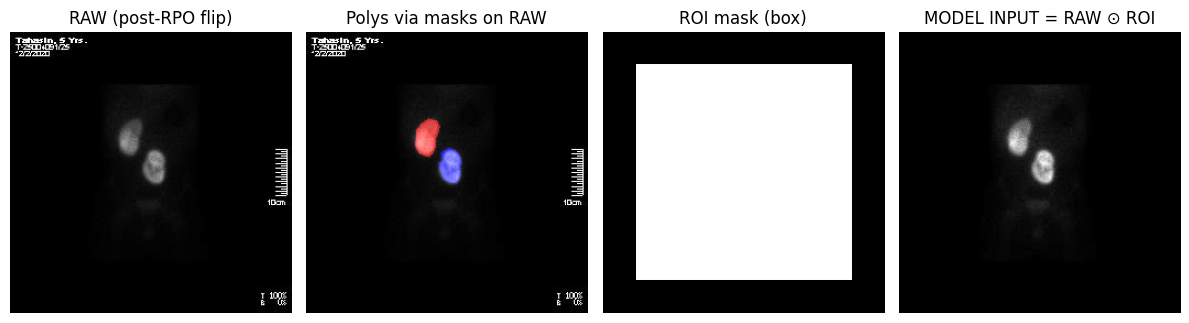

In [24]:
# CELL 16 — Visual PROOF: Raw vs ROI-masked (model input) + masks

s = train_ds[random.randint(0, len(train_ds)-1)]

Iraw = s["I_raw"].squeeze(0).numpy()
I    = s["I"].squeeze(0).numpy()
ROI  = s["ROI"].squeeze(0).numpy()
ML   = s["ML"].squeeze(0).numpy()
MR   = s["MR"].squeeze(0).numpy()

overlay = np.stack([Iraw, Iraw, Iraw], axis=-1)
overlay[...,0] = np.clip(overlay[...,0] + 0.6*ML, 0, 1)
overlay[...,2] = np.clip(overlay[...,2] + 0.6*MR, 0, 1)

print("PROOF — filename:", s["filename"], "| VIEW:", s["view"])
print("PROOF — left_present/right_present:", int(s["left_present"].item()), int(s["right_present"].item()))

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(Iraw, cmap="gray"); plt.title("RAW (post-RPO flip)"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(overlay); plt.title("Polys via masks on RAW"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(ROI, cmap="gray"); plt.title("ROI mask (box)"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(I, cmap="gray"); plt.title("MODEL INPUT = RAW ⊙ ROI"); plt.axis("off")
plt.tight_layout()
plt.show()


PROOF — checking indices: [951, 1367, 1087, 1144, 1219, 649, 1546, 906]


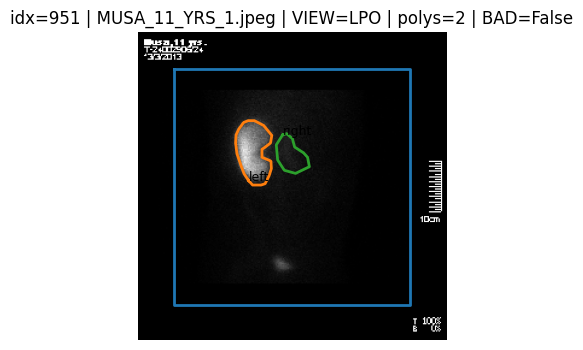

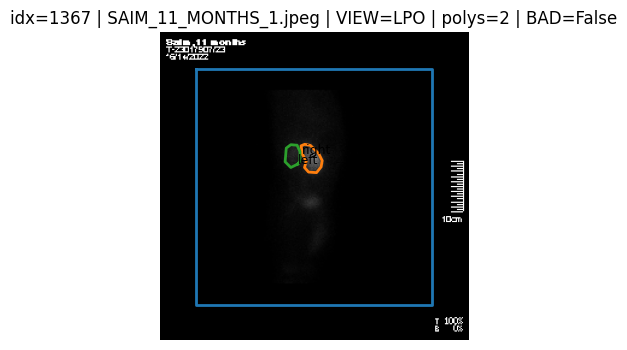

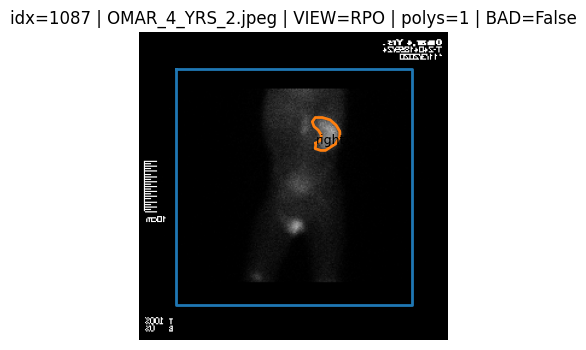

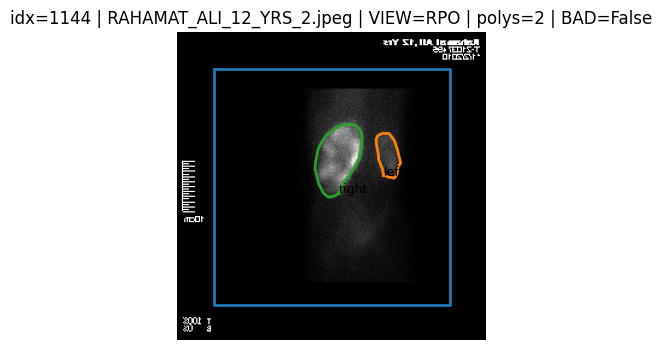

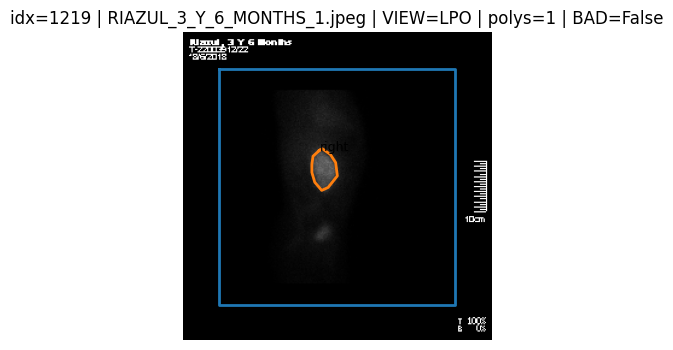

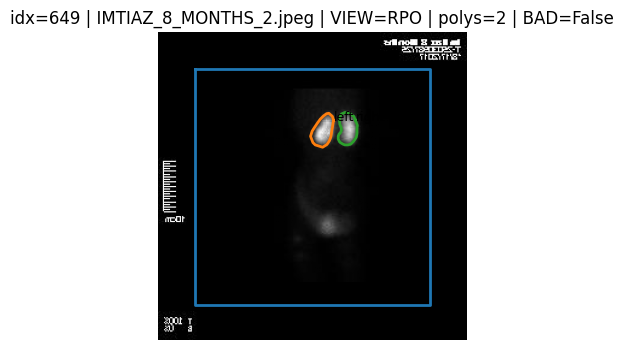

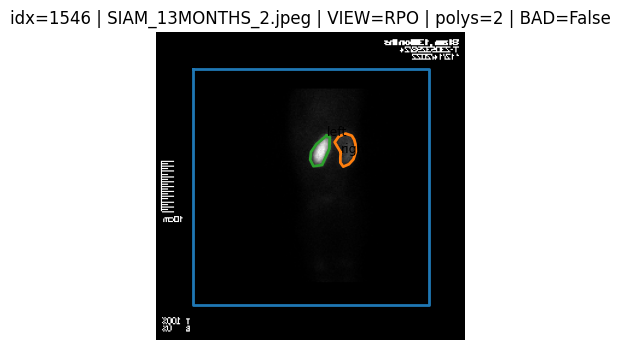

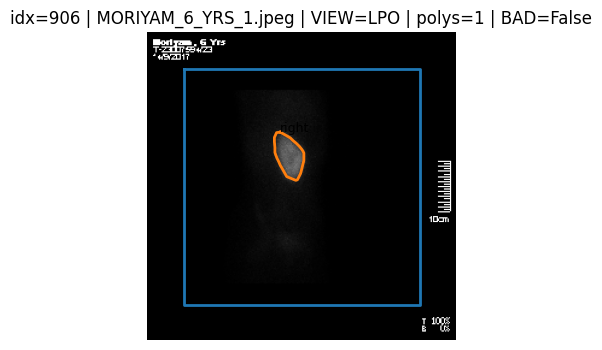


PROOF SUMMARY:
Total polygons checked: 13
Polygons with ANY point outside crop: 0


In [25]:
# CELL 16.2 — PROOF: do GT polygons fit inside crop box? (no training changes)

CROP_X0, CROP_Y0 = 30, 30
CROP_X1, CROP_Y1 = 226, 226  # intended crop limits on 256x256

def polygon_points_from_regions(regions):
    polys = []  # list of (label, [(x,y),...])
    for r in regions:
        if not isinstance(r, dict):
            continue
        sa = r.get("shape_attributes", {})
        ra = r.get("region_attributes", {})
        xs = sa.get("all_points_x", None)
        ys = sa.get("all_points_y", None)
        if xs is None or ys is None or len(xs) < 3:
            continue
        label = str(ra.get("label", "")).strip().lower()
        pts = [(float(xs[i]), float(ys[i])) for i in range(len(xs))]
        polys.append((label, pts))
    return polys

def points_outside_crop(pts):
    # Strict: must satisfy CROP_X0 <= x <= CROP_X1 and CROP_Y0 <= y <= CROP_Y1
    # (we'll treat border as allowed)
    out = []
    for (x, y) in pts:
        if not (CROP_X0 <= x <= CROP_X1 and CROP_Y0 <= y <= CROP_Y1):
            out.append((x, y))
    return out

def draw_polys_and_crop(I_01, polys, title=""):
    # I_01: 256x256 in [0,1]
    fig = plt.figure(figsize=(10,4))
    ax = plt.gca()
    ax.imshow(I_01, cmap="gray")

    # crop box
    ax.plot([CROP_X0, CROP_X1, CROP_X1, CROP_X0, CROP_X0],
            [CROP_Y0, CROP_Y0, CROP_Y1, CROP_Y1, CROP_Y0],
            linewidth=2)

    # polygons
    for (lab, pts) in polys:
        xs = [p[0] for p in pts] + [pts[0][0]]
        ys = [p[1] for p in pts] + [pts[0][1]]
        ax.plot(xs, ys, linewidth=2)
        # label near first point
        ax.text(xs[0], ys[0], lab, fontsize=9)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

# pick random examples and test
k = min(8, len(train_ds))
idxs = random.sample(range(len(train_ds)), k=k)
print("PROOF — checking indices:", idxs)

total_polys = 0
total_bad_polys = 0

for idx in idxs:
    row = train_df.iloc[idx]  # NOTE: train_ds uses train_df order; this matches because train_ds wraps train_df
    fn = link_to_filename(row[COL_LINK])
    view = str(row[COL_VIEW]).strip().upper()

    # load the SAME way dataset does (including RPO flip), but here we only need raw I
    img_path = resolve_image_path_strict(row[COL_LINK], LINK_BASE_DIR)
    I = load_img_gray_256(img_path)

    # get raw polygons
    polys = polygon_points_from_regions(ann_map[fn])

    # If VIEW==RPO, dataset flips IMAGE and MASKS.
    # For polygon fitting check, we should flip polygon x coords too (to match what model sees).
    if view == "RPO":
        flipped = []
        for lab, pts in polys:
            pts2 = [(255 - x, y) for (x, y) in pts]  # flip x for 256-wide image
            flipped.append((lab, pts2))
        polys = flipped
        I = np.fliplr(I).copy()

    # check out-of-crop points per polygon
    bad_here = False
    for lab, pts in polys:
        total_polys += 1
        out_pts = points_outside_crop(pts)
        if len(out_pts) > 0:
            bad_here = True
            total_bad_polys += 1

    # visualize
    title = f"idx={idx} | {fn} | VIEW={view} | polys={len(polys)} | BAD={bad_here}"
    draw_polys_and_crop(I, polys, title=title)

print("\nPROOF SUMMARY:")
print("Total polygons checked:", total_polys)
print("Polygons with ANY point outside crop:", total_bad_polys)


In [26]:
# CELL 17 — REPLACE: Model
# Changes:
# - Size heads become PRESENT-only: 4 classes (smaller/normal/bigger/po)
# - Uptake heads become PRESENT-only: 2 classes (normal/reduced)
# - Scar heads remain FULL: 3 classes (not applicable/single/multiple)

MASK_FEAT_DIM = 11  # from mask_features()

class SmallCNN(nn.Module):
    def __init__(self, in_ch: int, feat_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(256, feat_dim)

    def forward(self, x):
        x = self.net(x).flatten(1)
        return self.fc(x)

class DMSASymbioticNet(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.enc_ctx = SmallCNN(in_ch=1, feat_dim=feat_dim)   # raw I -> FC
        self.enc_foc = SmallCNN(in_ch=2, feat_dim=feat_dim)   # [I*Mask, Mask] -> F*

        # separate gate boxes
        self.left_present_head  = nn.Linear(feat_dim, 1)
        self.right_present_head = nn.Linear(feat_dim, 1)

        # global heads
        gdim = feat_dim * 3 + MASK_FEAT_DIM
        self.anat2k_head = nn.Linear(gdim, len(anat2k2id))    # {normal, ectopic, horshoe}
        self.pos_head    = nn.Linear(gdim, len(pos2id))

        # side heads
        # Size PRESENT-only
        self.sizeL_p_head = nn.Linear(feat_dim, len(size_p2id))
        self.sizeR_p_head = nn.Linear(feat_dim, len(size_p2id))

        # Scar FULL (includes not applicable even when present)
        self.scar_L_head = nn.Linear(feat_dim, len(scar2id))
        self.scar_R_head = nn.Linear(feat_dim, len(scar2id))

        # Uptake PRESENT-only (still uses concat(FC, Fside) as you wanted)
        self.uptakeL_p_head = nn.Linear(feat_dim * 2, len(uptake_p2id))
        self.uptakeR_p_head = nn.Linear(feat_dim * 2, len(uptake_p2id))

    def forward(self, I, I_L, ML, I_R, MR, feats):
        FC = self.enc_ctx(I)
        FL = self.enc_foc(torch.cat([I_L, ML], dim=1))
        FR = self.enc_foc(torch.cat([I_R, MR], dim=1))

        lp_logit = self.left_present_head(FL).squeeze(1)
        rp_logit = self.right_present_head(FR).squeeze(1)

        g = torch.cat([FC, FL, FR, feats], dim=1)
        anat2k_logits = self.anat2k_head(g)
        pos_logits    = self.pos_head(g)

        sizeL_p_logits = self.sizeL_p_head(FL)
        sizeR_p_logits = self.sizeR_p_head(FR)

        scarL_logits = self.scar_L_head(FL)
        scarR_logits = self.scar_R_head(FR)

        uptakeL_p_logits = self.uptakeL_p_head(torch.cat([FC, FL], dim=1))
        uptakeR_p_logits = self.uptakeR_p_head(torch.cat([FC, FR], dim=1))

        return {
            "lp_logit": lp_logit,
            "rp_logit": rp_logit,

            "anat2k_logits": anat2k_logits,
            "pos_logits": pos_logits,

            "sizeL_p_logits": sizeL_p_logits,
            "sizeR_p_logits": sizeR_p_logits,

            "scarL_logits": scarL_logits,
            "scarR_logits": scarR_logits,

            "uptakeL_p_logits": uptakeL_p_logits,
            "uptakeR_p_logits": uptakeR_p_logits,
        }

model = DMSASymbioticNet(feat_dim=256).to(DEVICE)

print("OK — model rebuilt with conditional PRESENT-only Size/Uptake.")
print("PROOF — Size_p classes:", size_p2id)
print("PROOF — Uptake_p classes:", uptake_p2id)
print("PROOF — Scar classes:", scar2id)


OK — model rebuilt with conditional PRESENT-only Size/Uptake.
PROOF — Size_p classes: {'bigger': 0, 'normal': 1, 'po': 2, 'smaller': 3}
PROOF — Uptake_p classes: {'normal': 0, 'reduced': 1}
PROOF — Scar classes: {'multiple': 0, 'not applicable': 1, 'single': 2}


In [27]:
# CELL 18 — REPLACE (SAFE): Loss with TEMPERED + CAPPED class weights for Size_p only
# - Size_p weighted with sqrt-inv-freq + cap
# - Uptake_p unweighted (for now)
# - Scar full unweighted
# - Anatomy2K/Position masked by target != -1

import numpy as np
import torch
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()
ce_none = nn.CrossEntropyLoss(reduction="none")

def _to_device_weight(w, device):
    return torch.tensor(w, dtype=torch.float32, device=device)

def ce_masked_weighted(logits, target, weight=None):
    """
    logits: [B,C], target: [B] with -1 for ignore
    weight: torch.FloatTensor [C] or None
    """
    t = target.to(logits.device)
    t_clamped = t.clamp(min=0)
    if weight is None:
        loss = ce_none(logits, t_clamped)
    else:
        ce_w = nn.CrossEntropyLoss(weight=weight, reduction="none")
        loss = ce_w(logits, t_clamped)
    mask = (t >= 0).float()
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device)
    return (loss * mask).sum() / mask.sum()

def _compute_present_counts_size(train_df):
    counts = np.zeros(len(size_p2id), dtype=np.int64)
    for col in [COL_SIZE_L, COL_SIZE_R]:
        for v in train_df[col].tolist():
            s = canon_size(v)
            if s in size_p2id:
                counts[size_p2id[s]] += 1
    return counts

def _tempered_capped_weights(counts, alpha=0.5, cap=3.0, eps=1.0):
    # w_i = (total/(k*(count_i+eps)))^alpha , then normalize mean=1, then cap
    total = float(counts.sum())
    k = float(len(counts))
    base = total / (k * (counts.astype(np.float32) + eps))
    w = np.power(base, alpha)

    # normalize mean to 1
    w = w / (w.mean() + 1e-8)

    # cap (both sides, just in case)
    w = np.clip(w, 1.0 / cap, cap)

    # re-normalize after clip
    w = w / (w.mean() + 1e-8)
    return w

# ---- Size weights (safe) ----
SIZE_ALPHA = 0.5
SIZE_CAP = 3.0

size_counts = _compute_present_counts_size(train_df)
size_w_np = _tempered_capped_weights(size_counts, alpha=SIZE_ALPHA, cap=SIZE_CAP, eps=1.0)

print("PROOF — Size_p class names:", list(size_p2id.keys()))
print("PROOF — Size_p counts:", size_counts.tolist())
print("PROOF — Size_p weights (tempered+capped):", [float(x) for x in size_w_np])
print("PROOF — weight min/max:", float(size_w_np.min()), float(size_w_np.max()))

LOSS_W = {
    "lp": 1.0, "rp": 1.0,
    "anat2k": 1.0, "pos": 1.0,
    "size": 1.0, "scar": 1.0, "uptake": 1.0,
}

def compute_loss(out, batch, w=LOSS_W):
    dev = out["lp_logit"].device
    size_w = _to_device_weight(size_w_np, dev)

    loss_lp = bce(out["lp_logit"], batch["left_present"].to(dev))
    loss_rp = bce(out["rp_logit"], batch["right_present"].to(dev))

    loss_anat2k = ce_masked_weighted(out["anat2k_logits"], batch["anatomy_2k"], weight=None)
    loss_pos    = ce_masked_weighted(out["pos_logits"],    batch["position"],  weight=None)

    # Size PRESENT-only (safe weighted)
    loss_sizeL = ce_masked_weighted(out["sizeL_p_logits"], batch["size_L_p"], weight=size_w)
    loss_sizeR = ce_masked_weighted(out["sizeR_p_logits"], batch["size_R_p"], weight=size_w)
    loss_size  = 0.5 * (loss_sizeL + loss_sizeR)

    # Scar FULL (unweighted)
    loss_scarL = ce_masked_weighted(out["scarL_logits"], batch["scar_L"], weight=None)
    loss_scarR = ce_masked_weighted(out["scarR_logits"], batch["scar_R"], weight=None)
    loss_scar  = 0.5 * (loss_scarL + loss_scarR)

    # Uptake PRESENT-only (unweighted for stability)
    loss_uptL  = ce_masked_weighted(out["uptakeL_p_logits"], batch["uptake_L_p"], weight=None)
    loss_uptR  = ce_masked_weighted(out["uptakeR_p_logits"], batch["uptake_R_p"], weight=None)
    loss_upt   = 0.5 * (loss_uptL + loss_uptR)

    total = (
        w["lp"]*loss_lp + w["rp"]*loss_rp +
        w["anat2k"]*loss_anat2k + w["pos"]*loss_pos +
        w["size"]*loss_size + w["scar"]*loss_scar + w["uptake"]*loss_upt
    )

    parts = {
        "total": total.detach().item(),
        "lp": loss_lp.detach().item(),
        "rp": loss_rp.detach().item(),
        "anat2k": loss_anat2k.detach().item(),
        "pos": loss_pos.detach().item(),
        "size": loss_size.detach().item(),
        "scar": loss_scar.detach().item(),
        "uptake": loss_upt.detach().item(),
    }
    return total, parts

print("OK — compute_loss updated (SAFE Size weighting; Uptake unweighted).")


PROOF — Size_p class names: ['bigger', 'normal', 'po', 'smaller']
PROOF — Size_p counts: [291, 2505, 93, 388]
PROOF — Size_p weights (tempered+capped): [1.007495641708374, 0.34390944242477417, 1.7757043838500977, 0.8728905916213989]
PROOF — weight min/max: 0.34390944242477417 1.7757043838500977
OK — compute_loss updated (SAFE Size weighting; Uptake unweighted).


In [28]:
# CELL 19 — REPLACE: PROOF forward pass sanity (keys updated)

model.eval()
b = next(iter(train_loader))

with torch.no_grad():
    out = model(
        I=b["I"].to(DEVICE),
        I_L=b["I_L"].to(DEVICE),
        ML=b["ML"].to(DEVICE),
        I_R=b["I_R"].to(DEVICE),
        MR=b["MR"].to(DEVICE),
        feats=b["feats"].to(DEVICE),
    )

print("PROOF — shapes:")
print(" lp_logit:", out["lp_logit"].shape, "| rp_logit:", out["rp_logit"].shape)
print(" anat2k:", out["anat2k_logits"].shape, "| pos:", out["pos_logits"].shape)
print(" sizeL_p:", out["sizeL_p_logits"].shape, "| sizeR_p:", out["sizeR_p_logits"].shape)
print(" scarL:", out["scarL_logits"].shape, "| scarR:", out["scarR_logits"].shape)
print(" uptL_p:", out["uptakeL_p_logits"].shape, "| uptR_p:", out["uptakeR_p_logits"].shape)

print("\nPROOF — targets in this batch:")
print(" anatomy_2k unique:", torch.unique(b["anatomy_2k"]))
print(" size_L_p unique:", torch.unique(b["size_L_p"]), "| size_R_p unique:", torch.unique(b["size_R_p"]))
print(" uptake_L_p unique:", torch.unique(b["uptake_L_p"]), "| uptake_R_p unique:", torch.unique(b["uptake_R_p"]))
print(" size_L_full unique:", torch.unique(b["size_L_full"]), "| uptake_L_full unique:", torch.unique(b["uptake_L_full"]))

model.train()


PROOF — shapes:
 lp_logit: torch.Size([16]) | rp_logit: torch.Size([16])
 anat2k: torch.Size([16, 3]) | pos: torch.Size([16, 2])
 sizeL_p: torch.Size([16, 4]) | sizeR_p: torch.Size([16, 4])
 scarL: torch.Size([16, 3]) | scarR: torch.Size([16, 3])
 uptL_p: torch.Size([16, 2]) | uptR_p: torch.Size([16, 2])

PROOF — targets in this batch:
 anatomy_2k unique: tensor([-1,  0,  2])
 size_L_p unique: tensor([-1,  0,  1,  3]) | size_R_p unique: tensor([-1,  1,  3])
 uptake_L_p unique: tensor([-1,  0,  1]) | uptake_R_p unique: tensor([-1,  0,  1])
 size_L_full unique: tensor([0, 1, 2, 4]) | uptake_L_full unique: tensor([0, 1, 2])


DMSASymbioticNet(
  (enc_ctx): SmallCNN(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=1)
    )
    (fc): Linear(in_features=256, out_features=256, bias=True)
  )
  (enc_foc): SmallCNN(
    (net): Sequential(
      (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (

In [29]:
# CELL 20 — REPLACE: Training loop + VAL (UPDATED for conditional Size/Uptake present-only + Scar full + Anatomy2K)
# - Uses compute_loss() parts keys: total, lp, rp, anat2k, pos, size, scar, uptake
# - VAL reports:
#   * gate acc (LP/RP) + KidneyCount acc
#   * pos acc
#   * anat2k acc (only where GT anatomy_2k != -1)
#   * size/uptake PRESENT-only acc (only where *_p != -1)
#   * size/uptake/scar FINAL FULL acc using your rules (forced outputs when side absent)

import time
import numpy as np
from tqdm.auto import tqdm

def _dev(x):
    # DEVICE might be torch.device or str
    return torch.device(x) if isinstance(x, str) else x

_DEVICE = _dev(DEVICE)

single_id = anat2id[ANAT_SINGLE_NAME]

def eval_epoch(loader):
    model.eval()

    totals = []
    n = 0

    # gate/kc
    acc_lp = acc_rp = acc_kc = 0

    # global
    acc_pos = 0
    acc_anat2k = 0
    anat2k_count = 0  # only where GT anatomy_2k != -1

    # present-only head accuracies (evaluate only where target != -1)
    acc_sizeL_p = acc_sizeR_p = 0
    cnt_sizeL_p = cnt_sizeR_p = 0
    acc_uptL_p  = acc_uptR_p  = 0
    cnt_uptL_p  = cnt_uptR_p  = 0

    # FINAL FULL accuracies using rules (compare to *_full labels from dataset)
    acc_sizeL_full = acc_sizeR_full = 0
    acc_uptL_full  = acc_uptR_full  = 0
    acc_scarL_full = acc_scarR_full = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="VAL", leave=True):
            out = model(
                I=batch["I"].to(_DEVICE),
                I_L=batch["I_L"].to(_DEVICE),
                ML=batch["ML"].to(_DEVICE),
                I_R=batch["I_R"].to(_DEVICE),
                MR=batch["MR"].to(_DEVICE),
                feats=batch["feats"].to(_DEVICE),
            )

            loss, parts = compute_loss(out, batch)
            totals.append(parts)

            B = batch["I"].shape[0]
            n += B

            # ----- gates -----
            lp_pred = (torch.sigmoid(out["lp_logit"]) > 0.5).long().cpu()
            rp_pred = (torch.sigmoid(out["rp_logit"]) > 0.5).long().cpu()
            lp_gt = batch["left_present"].long()
            rp_gt = batch["right_present"].long()

            acc_lp += (lp_pred == lp_gt).sum().item()
            acc_rp += (rp_pred == rp_gt).sum().item()

            kc_pred = lp_pred + rp_pred
            kc_gt   = batch["kidney_count"].long()
            acc_kc += (kc_pred == kc_gt).sum().item()

            # ----- position -----
            pos_pred = out["pos_logits"].argmax(1).cpu()
            acc_pos += (pos_pred == batch["position"]).sum().item()

            # ----- anatomy_2k head accuracy (only where GT != -1) -----
            gt_a2k = batch["anatomy_2k"]
            m_a2k = (gt_a2k >= 0)
            if m_a2k.any():
                pred_a2k = out["anat2k_logits"].argmax(1).cpu()
                acc_anat2k += (pred_a2k[m_a2k] == gt_a2k[m_a2k]).sum().item()
                anat2k_count += int(m_a2k.sum().item())

            # ----- present-only size accuracies -----
            pred_szL_p = out["sizeL_p_logits"].argmax(1).cpu()
            pred_szR_p = out["sizeR_p_logits"].argmax(1).cpu()
            gt_szL_p = batch["size_L_p"].cpu()
            gt_szR_p = batch["size_R_p"].cpu()

            m_szL = (gt_szL_p >= 0)
            if m_szL.any():
                acc_sizeL_p += (pred_szL_p[m_szL] == gt_szL_p[m_szL]).sum().item()
                cnt_sizeL_p += int(m_szL.sum().item())

            m_szR = (gt_szR_p >= 0)
            if m_szR.any():
                acc_sizeR_p += (pred_szR_p[m_szR] == gt_szR_p[m_szR]).sum().item()
                cnt_sizeR_p += int(m_szR.sum().item())

            # ----- present-only uptake accuracies -----
            pred_upL_p = out["uptakeL_p_logits"].argmax(1).cpu()
            pred_upR_p = out["uptakeR_p_logits"].argmax(1).cpu()
            gt_upL_p = batch["uptake_L_p"].cpu()
            gt_upR_p = batch["uptake_R_p"].cpu()

            m_upL = (gt_upL_p >= 0)
            if m_upL.any():
                acc_uptL_p += (pred_upL_p[m_upL] == gt_upL_p[m_upL]).sum().item()
                cnt_uptL_p += int(m_upL.sum().item())

            m_upR = (gt_upR_p >= 0)
            if m_upR.any():
                acc_uptR_p += (pred_upR_p[m_upR] == gt_upR_p[m_upR]).sum().item()
                cnt_uptR_p += int(m_upR.sum().item())

            # ----- FINAL FULL predictions (forced when side absent) -----
            gt_sizeL_full = batch["size_L_full"].cpu()
            gt_sizeR_full = batch["size_R_full"].cpu()
            gt_uptL_full  = batch["uptake_L_full"].cpu()
            gt_uptR_full  = batch["uptake_R_full"].cpu()
            gt_scarL_full = batch["scar_L"].cpu()
            gt_scarR_full = batch["scar_R"].cpu()

            pred_scarL = out["scarL_logits"].argmax(1).cpu()
            pred_scarR = out["scarR_logits"].argmax(1).cpu()

            pred_sizeL_full = torch.empty_like(gt_sizeL_full)
            pred_sizeR_full = torch.empty_like(gt_sizeR_full)
            pred_uptL_full  = torch.empty_like(gt_uptL_full)
            pred_uptR_full  = torch.empty_like(gt_uptR_full)
            pred_scarL_full = torch.empty_like(gt_scarL_full)
            pred_scarR_full = torch.empty_like(gt_scarR_full)

            for i in range(B):
                if lp_pred[i].item() == 0:
                    pred_sizeL_full[i] = SIZE_FULL_NV_ID
                    pred_uptL_full[i]  = UPTAKE_FULL_NA_ID
                    pred_scarL_full[i] = SCAR_FULL_NA_ID
                else:
                    pred_sizeL_full[i] = size_p_to_full[int(pred_szL_p[i].item())]
                    pred_uptL_full[i]  = uptake_p_to_full[int(pred_upL_p[i].item())]
                    pred_scarL_full[i] = int(pred_scarL[i].item())

                if rp_pred[i].item() == 0:
                    pred_sizeR_full[i] = SIZE_FULL_NV_ID
                    pred_uptR_full[i]  = UPTAKE_FULL_NA_ID
                    pred_scarR_full[i] = SCAR_FULL_NA_ID
                else:
                    pred_sizeR_full[i] = size_p_to_full[int(pred_szR_p[i].item())]
                    pred_uptR_full[i]  = uptake_p_to_full[int(pred_upR_p[i].item())]
                    pred_scarR_full[i] = int(pred_scarR[i].item())

            acc_sizeL_full += (pred_sizeL_full == gt_sizeL_full).sum().item()
            acc_sizeR_full += (pred_sizeR_full == gt_sizeR_full).sum().item()
            acc_uptL_full  += (pred_uptL_full  == gt_uptL_full ).sum().item()
            acc_uptR_full  += (pred_uptR_full  == gt_uptR_full ).sum().item()
            acc_scarL_full += (pred_scarL_full == gt_scarL_full).sum().item()
            acc_scarR_full += (pred_scarR_full == gt_scarR_full).sum().item()

    mean_parts = {k: float(np.mean([d[k] for d in totals])) for k in totals[0].keys()}

    # base acc
    mean_parts["lp_acc"] = acc_lp / max(1, n)
    mean_parts["rp_acc"] = acc_rp / max(1, n)
    mean_parts["kc_acc"] = acc_kc / max(1, n)
    mean_parts["pos_acc"] = acc_pos / max(1, n)

    # anatomy head acc
    mean_parts["anat2k_acc"] = acc_anat2k / max(1, anat2k_count)
    mean_parts["anat2k_count"] = anat2k_count

    # present-only acc
    mean_parts["sizeL_p_acc"] = acc_sizeL_p / max(1, cnt_sizeL_p)
    mean_parts["sizeR_p_acc"] = acc_sizeR_p / max(1, cnt_sizeR_p)
    mean_parts["uptakeL_p_acc"] = acc_uptL_p / max(1, cnt_uptL_p)
    mean_parts["uptakeR_p_acc"] = acc_uptR_p / max(1, cnt_uptR_p)
    mean_parts["sizeL_p_n"] = cnt_sizeL_p
    mean_parts["sizeR_p_n"] = cnt_sizeR_p
    mean_parts["uptakeL_p_n"] = cnt_uptL_p
    mean_parts["uptakeR_p_n"] = cnt_uptR_p

    # final full acc
    mean_parts["sizeL_full_acc"] = acc_sizeL_full / max(1, n)
    mean_parts["sizeR_full_acc"] = acc_sizeR_full / max(1, n)
    mean_parts["uptakeL_full_acc"] = acc_uptL_full / max(1, n)
    mean_parts["uptakeR_full_acc"] = acc_uptR_full / max(1, n)
    mean_parts["scarL_full_acc"] = acc_scarL_full / max(1, n)
    mean_parts["scarR_full_acc"] = acc_scarR_full / max(1, n)

    model.train()
    return mean_parts


opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

if "EPOCHS" not in globals():
    EPOCHS = 10

best_val = 1e18
# CELL 20 — SMALL PATCH (OPTIONAL): change checkpoint filename for clarity (modelv5)
# Put this line near the top of CELL 20 where best_path is defined.

best_path = BASE_DIR / "modelv5_roi_best.pt"
print("PROOF — best checkpoint path:", best_path)


for ep in range(1, EPOCHS + 1):
    model.train()
    ep_parts = []

    pbar = tqdm(train_loader, desc=f"TRAIN {ep}/{EPOCHS}", leave=True)
    t0 = time.time()

    for batch in pbar:
        opt.zero_grad(set_to_none=True)

        out = model(
            I=batch["I"].to(_DEVICE),
            I_L=batch["I_L"].to(_DEVICE),
            ML=batch["ML"].to(_DEVICE),
            I_R=batch["I_R"].to(_DEVICE),
            MR=batch["MR"].to(_DEVICE),
            feats=batch["feats"].to(_DEVICE),
        )

        loss, parts = compute_loss(out, batch)
        loss.backward()
        opt.step()

        ep_parts.append(parts)
        pbar.set_postfix(
            loss=f"{parts['total']:.3f}",
            lp=f"{parts['lp']:.2f}",
            rp=f"{parts['rp']:.2f}",
            anat2k=f"{parts['anat2k']:.2f}",
            pos=f"{parts['pos']:.2f}",
            size=f"{parts['size']:.2f}",
            scar=f"{parts['scar']:.2f}",
            upt=f"{parts['uptake']:.2f}",
        )

    train_mean = {k: float(np.mean([d[k] for d in ep_parts])) for k in ep_parts[0].keys()}
    val_mean = eval_epoch(val_loader)

    print(f"\n[EPOCH {ep}] train_total={train_mean['total']:.4f} | val_total={val_mean['total']:.4f} | time={time.time()-t0:.1f}s")
    print(
        "          VAL acc: "
        f"LP={val_mean['lp_acc']:.3f} RP={val_mean['rp_acc']:.3f} KC={val_mean['kc_acc']:.3f} "
        f"POS={val_mean['pos_acc']:.3f} ANAT2K={val_mean['anat2k_acc']:.3f} (n={val_mean['anat2k_count']})"
    )
    print(
        "          VAL present-only: "
        f"SizeL_p={val_mean['sizeL_p_acc']:.3f} (n={val_mean['sizeL_p_n']}), "
        f"SizeR_p={val_mean['sizeR_p_acc']:.3f} (n={val_mean['sizeR_p_n']}), "
        f"UptL_p={val_mean['uptakeL_p_acc']:.3f} (n={val_mean['uptakeL_p_n']}), "
        f"UptR_p={val_mean['uptakeR_p_acc']:.3f} (n={val_mean['uptakeR_p_n']})"
    )
    print(
        "          VAL final-full: "
        f"SizeL={val_mean['sizeL_full_acc']:.3f} SizeR={val_mean['sizeR_full_acc']:.3f} "
        f"UptL={val_mean['uptakeL_full_acc']:.3f} UptR={val_mean['uptakeR_full_acc']:.3f} "
        f"ScarL={val_mean['scarL_full_acc']:.3f} ScarR={val_mean['scarR_full_acc']:.3f}"
    )

    if val_mean["total"] < best_val:
        best_val = val_mean["total"]
        torch.save({"epoch": ep, "model": model.state_dict(), "val": val_mean}, best_path)
        print("✅ Saved best:", best_path)


PROOF — best checkpoint path: F:\Bracu\THESIS\Final Defence\Dataset\code\modelv5_roi_best.pt


TRAIN 1/10:   0%|          | 0/114 [00:00<?, ?it/s]

VAL:   0%|          | 0/15 [00:00<?, ?it/s]


[EPOCH 1] train_total=3.1461 | val_total=3.0969 | time=13.4s
          VAL acc: LP=0.899 RP=0.899 KC=0.798 POS=0.908 ANAT2K=0.884 (n=190)
          VAL present-only: SizeL_p=0.734 (n=214), SizeR_p=0.734 (n=214), UptL_p=0.650 (n=214), UptR_p=0.664 (n=214)
          VAL final-full: SizeL=0.660 SizeR=0.660 UptL=0.584 UptR=0.597 ScarL=0.887 ScarR=0.912
✅ Saved best: F:\Bracu\THESIS\Final Defence\Dataset\code\modelv5_roi_best.pt


TRAIN 2/10:   0%|          | 0/114 [00:00<?, ?it/s]

...

VAL:   0%|          | 0/15 [00:00<?, ?it/s]


[EPOCH 9] train_total=2.0484 | val_total=2.3622 | time=13.2s
          VAL acc: LP=1.000 RP=1.000 KC=1.000 POS=0.908 ANAT2K=0.884 (n=190)
          VAL present-only: SizeL_p=0.696 (n=214), SizeR_p=0.771 (n=214), UptL_p=0.794 (n=214), UptR_p=0.729 (n=214)
          VAL final-full: SizeL=0.727 SizeR=0.794 UptL=0.815 UptR=0.756 ScarL=0.887 ScarR=0.912


TRAIN 10/10:   0%|          | 0/114 [00:00<?, ?it/s]

VAL:   0%|          | 0/15 [00:00<?, ?it/s]


[EPOCH 10] train_total=2.0230 | val_total=2.3559 | time=13.1s
          VAL acc: LP=1.000 RP=1.000 KC=1.000 POS=0.908 ANAT2K=0.884 (n=190)
          VAL present-only: SizeL_p=0.743 (n=214), SizeR_p=0.766 (n=214), UptL_p=0.818 (n=214), UptR_p=0.738 (n=214)
          VAL final-full: SizeL=0.769 SizeR=0.790 UptL=0.836 UptR=0.765 ScarL=0.887 ScarR=0.912


In [30]:
# CELL 21 — Load best checkpoint + TEST evaluation (core metrics)

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

test_mean = eval_epoch(test_loader)
print("TEST metrics:")
for k,v in test_mean.items():
    print(f"{k:10s}: {v:.4f}")


C:\Users\User\AppData\Local\Temp\ipykernel_12656\3276678561.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=DEVICE)


VAL:   0%|          | 0/15 [00:00<?, ?it/s]

TEST metrics:
total     : 2.1761
lp        : 0.0073
rp        : 0.0243
anat2k    : 0.4053
pos       : 0.3186
size      : 0.6901
scar      : 0.2003
uptake    : 0.5303
lp_acc    : 1.0000
rp_acc    : 1.0000
kc_acc    : 1.0000
pos_acc   : 0.9021
anat2k_acc: 0.8878
anat2k_count: 205.0000
sizeL_p_acc: 0.7636
sizeR_p_acc: 0.7136
uptakeL_p_acc: 0.8409
uptakeR_p_acc: 0.7000
sizeL_p_n : 220.0000
sizeR_p_n : 220.0000
uptakeL_p_n: 220.0000
uptakeR_p_n: 220.0000
sizeL_full_acc: 0.7787
sizeR_full_acc: 0.7319
uptakeL_full_acc: 0.8511
uptakeR_full_acc: 0.7191
scarL_full_acc: 0.9489
scarR_full_acc: 0.9489


In [31]:
# CELL 22 — REPLACE: Show a few test predictions (decoded) for CONDITIONAL Anatomy + CONDITIONAL Size/Uptake

id2anat = {v:k for k,v in anat2id.items()}     # includes 'single'
id2pos  = {v:k for k,v in pos2id.items()}
id2size_full = {v:k for k,v in size2id.items()}   # includes 'nv'
id2scar = {v:k for k,v in scar2id.items()}        # includes 'not applicable'
id2upt_full  = {v:k for k,v in uptake2id.items()} # includes 'not applicable'

single_id = anat2id[ANAT_SINGLE_NAME]

model.eval()
batch = next(iter(test_loader))

with torch.no_grad():
    out = model(
        I=batch["I"].to(DEVICE),
        I_L=batch["I_L"].to(DEVICE),
        ML=batch["ML"].to(DEVICE),
        I_R=batch["I_R"].to(DEVICE),
        MR=batch["MR"].to(DEVICE),
        feats=batch["feats"].to(DEVICE),
    )

lp = (torch.sigmoid(out["lp_logit"]) > 0.5).long().cpu()
rp = (torch.sigmoid(out["rp_logit"]) > 0.5).long().cpu()
kc_pred = (lp + rp).numpy()
kc_gt   = (batch["left_present"].long() + batch["right_present"].long()).numpy()

# position
pos_pred = out["pos_logits"].argmax(1).cpu().numpy()

# anatomy conditional
anat2k_pred = out["anat2k_logits"].argmax(1).cpu().numpy()
anat_pred_name = []
anat_gt_name   = []
for i in range(len(kc_pred)):
    # pred anatomy
    if kc_pred[i] == 1:
        anat_pred_name.append(ANAT_SINGLE_NAME)
    else:
        anat_pred_name.append(id2anat2k[int(anat2k_pred[i])])

    # gt anatomy (from GT kidney_count)
    if kc_gt[i] == 1:
        anat_gt_name.append(ANAT_SINGLE_NAME)
    else:
        a2k = int(batch["anatomy_2k"][i].item())
        anat_gt_name.append(id2anat2k[a2k] if a2k >= 0 else "INVALID_GT")

# conditional Size/Uptake predictions (final FULL labels)
sizeL_p = out["sizeL_p_logits"].argmax(1).cpu().numpy()
sizeR_p = out["sizeR_p_logits"].argmax(1).cpu().numpy()
uptL_p  = out["uptakeL_p_logits"].argmax(1).cpu().numpy()
uptR_p  = out["uptakeR_p_logits"].argmax(1).cpu().numpy()

scarL = out["scarL_logits"].argmax(1).cpu().numpy()
scarR = out["scarR_logits"].argmax(1).cpu().numpy()

rows = []
for i in range(min(12, len(kc_pred))):
    LPp, RPp = int(lp[i].item()), int(rp[i].item())

    # FINAL predicted full labels via rules
    if LPp == 0:
        szL_pred_full = SIZE_FULL_NV_ID
        upL_pred_full = UPTAKE_FULL_NA_ID
        scL_pred_full = SCAR_FULL_NA_ID
    else:
        szL_pred_full = size_p_to_full[int(sizeL_p[i])]
        upL_pred_full = uptake_p_to_full[int(uptL_p[i])]
        scL_pred_full = int(scarL[i])

    if RPp == 0:
        szR_pred_full = SIZE_FULL_NV_ID
        upR_pred_full = UPTAKE_FULL_NA_ID
        scR_pred_full = SCAR_FULL_NA_ID
    else:
        szR_pred_full = size_p_to_full[int(sizeR_p[i])]
        upR_pred_full = uptake_p_to_full[int(uptR_p[i])]
        scR_pred_full = int(scarR[i])

    rows.append({
        "file": batch["filename"][i],
        "LP(gt/p)": f"{int(batch['left_present'][i].item())}/{LPp}",
        "RP(gt/p)": f"{int(batch['right_present'][i].item())}/{RPp}",
        "KC(gt/p)": f"{int(kc_gt[i])}/{int(kc_pred[i])}",
        "ANAT(gt/p)": f"{anat_gt_name[i]} / {anat_pred_name[i]}",
        "POS(gt/p)": f"{id2pos[int(batch['position'][i])]} / {id2pos[int(pos_pred[i])]}",
        "SizeL(gt/p)": f"{id2size_full[int(batch['size_L_full'][i])]} / {id2size_full[int(szL_pred_full)]}",
        "SizeR(gt/p)": f"{id2size_full[int(batch['size_R_full'][i])]} / {id2size_full[int(szR_pred_full)]}",
        "ScarL(gt/p)": f"{id2scar[int(batch['scar_L'][i])]} / {id2scar[int(scL_pred_full)]}",
        "ScarR(gt/p)": f"{id2scar[int(batch['scar_R'][i])]} / {id2scar[int(scR_pred_full)]}",
        "UptL(gt/p)": f"{id2upt_full[int(batch['uptake_L_full'][i])]} / {id2upt_full[int(upL_pred_full)]}",
        "UptR(gt/p)": f"{id2upt_full[int(batch['uptake_R_full'][i])]} / {id2upt_full[int(upR_pred_full)]}",
    })

pred_df = pd.DataFrame(rows)
display(pred_df)

model.train()


,file,LP(gt/p),RP(gt/p),KC(gt/p),ANAT(gt/p),POS(gt/p),SizeL(gt/p),SizeR(gt/p),ScarL(gt/p),ScarR(gt/p),UptL(gt/p),UptR(gt/p)
0,ABDULLAH_AL_MAMUN_40_DAYS.jpeg,1/1,0/0,1/1,single / single,normal renal fossa / normal renal fossa,normal / normal,nv / nv,not applicable / not applicable,not applicable / not applicable,normal / normal,not applicable / not applicable
1,ABDULLAH_AL_MAMUN_40_DAYS_1.jpeg,1/1,0/0,1/1,single / single,normal renal fossa / normal renal fossa,normal / normal,nv / nv,not applicable / not applicable,not applicable / not applicable,normal / normal,not applicable / not applicable
2,ABDULLAH_AL_MAMUN_40_DAYS_2.jpeg,1/1,0/0,1/1,single / single,normal renal fossa / normal renal fossa,normal / normal,nv / nv,not applicable / not applicable,not applicable / not applicable,normal / normal,not applicable / not applicable
3,ABU_RAYHAN_17_MONTHS.jpeg,0/0,1/1,1/1,single / single,normal renal fossa / normal renal fossa,nv / nv,normal / normal,not applicable / not applicable,not applicable / not applicable,not applicable / not applicable,normal / normal
4,ABU_RAYHAN_17_MONTHS_1.jpeg,0/0,1/1,1/1,single / single,normal renal fossa / normal renal fossa,nv / nv,normal / normal,not applicable / not applicable,not applicable / not applicable,not applicable / not applicable,normal / normal
5,ABU_RAYHAN_17_MONTHS_2.jpeg,0/0,1/1,1/1,single / single,normal renal fossa / normal renal fossa,nv / nv,normal / normal,not applicable / not applicable,not applicable / not applicable,not applicable / not applicable,normal / normal
6,ABU_SUFIAN_29_MONTHS.jpeg,1/1,1/1,2/2,normal / normal,normal renal fossa / normal renal fossa,normal / normal,normal / normal,not applicable / not applicable,not applicable / not applicable,normal / normal,normal / normal
7,ABU_SUFIAN_29_MONTHS_1.jpeg,1/1,1/1,2/2,normal / normal,normal renal fossa / normal renal fossa,normal / normal,normal / normal,not applicable / not applicable,not applicable / not applicable,normal / normal,normal / normal
8,ABU_SUFIAN_29_MONTHS_2.jpeg,1/1,1/1,2/2,normal / normal,normal renal fossa / normal renal fossa,normal / normal,normal / normal,not applicable / not applicable,not applicable / not applicable,normal / normal,normal / normal
9,ABUL_BASAR_30_YRS.jpeg,1/1,1/1,2/2,ectopic / normal,ectopic / normal renal fossa,normal / normal,normal / normal,not applicable / not applicable,not applicable / not applicable,normal / normal,normal / normal


DMSASymbioticNet(
  (enc_ctx): SmallCNN(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=1)
    )
    (fc): Linear(in_features=256, out_features=256, bias=True)
  )
  (enc_foc): SmallCNN(
    (net): Sequential(
      (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (

In [32]:
# CELL 23 — REPLACE: TEST accuracies (ALL) — conditional Anatomy + conditional Size/Uptake + scar full

from tqdm.auto import tqdm
import numpy as np

model.eval()

single_id = anat2id[ANAT_SINGLE_NAME]

def final_anatomy_pred_name(kc_pred, anat2k_pred):
    return ANAT_SINGLE_NAME if kc_pred == 1 else id2anat2k[int(anat2k_pred)]

counts = {
    "lp": [0,0], "rp": [0,0], "kc": [0,0],
    "anat_final": [0,0], "pos": [0,0],
    "sizeL": [0,0], "sizeR": [0,0],
    "scarL": [0,0], "scarR": [0,0],
    "uptakeL": [0,0], "uptakeR": [0,0],
}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="TEST accuracies", leave=True):
        out = model(
            I=batch["I"].to(DEVICE),
            I_L=batch["I_L"].to(DEVICE),
            ML=batch["ML"].to(DEVICE),
            I_R=batch["I_R"].to(DEVICE),
            MR=batch["MR"].to(DEVICE),
            feats=batch["feats"].to(DEVICE),
        )

        # gates
        lp_pred = (torch.sigmoid(out["lp_logit"]) > 0.5).long().cpu()
        rp_pred = (torch.sigmoid(out["rp_logit"]) > 0.5).long().cpu()
        lp_gt   = batch["left_present"].long()
        rp_gt   = batch["right_present"].long()

        counts["lp"][0] += (lp_pred == lp_gt).sum().item(); counts["lp"][1] += len(lp_gt)
        counts["rp"][0] += (rp_pred == rp_gt).sum().item(); counts["rp"][1] += len(rp_gt)

        kc_pred = lp_pred + rp_pred
        kc_gt   = batch["kidney_count"].long()
        counts["kc"][0] += (kc_pred == kc_gt).sum().item(); counts["kc"][1] += len(kc_gt)

        # position
        pos_pred = out["pos_logits"].argmax(1).cpu()
        pos_gt   = batch["position"].cpu()
        counts["pos"][0] += (pos_pred == pos_gt).sum().item(); counts["pos"][1] += len(pos_gt)

        # anatomy(final)
        anat2k_pred = out["anat2k_logits"].argmax(1).cpu()
        anat_final_pred = torch.empty_like(kc_pred)
        anat_final_gt   = torch.empty_like(kc_gt)

        for i in range(len(kc_gt)):
            # pred
            if kc_pred[i].item() == 1:
                anat_final_pred[i] = single_id
            else:
                anat_final_pred[i] = anat2id[id2anat2k[int(anat2k_pred[i].item())]]
            # gt
            if kc_gt[i].item() == 1:
                anat_final_gt[i] = single_id
            else:
                anat_final_gt[i] = anat2id[id2anat2k[int(batch["anatomy_2k"][i].item())]]

        counts["anat_final"][0] += (anat_final_pred == anat_final_gt).sum().item()
        counts["anat_final"][1] += len(anat_final_gt)

        # ---- Size/Uptake final full predictions (rule-based) ----
        sizeL_p = out["sizeL_p_logits"].argmax(1).cpu()
        sizeR_p = out["sizeR_p_logits"].argmax(1).cpu()
        uptL_p  = out["uptakeL_p_logits"].argmax(1).cpu()
        uptR_p  = out["uptakeR_p_logits"].argmax(1).cpu()

        scarL_pred = out["scarL_logits"].argmax(1).cpu()
        scarR_pred = out["scarR_logits"].argmax(1).cpu()

        # final full preds
        szL_pred_full = torch.empty_like(batch["size_L_full"])
        szR_pred_full = torch.empty_like(batch["size_R_full"])
        upL_pred_full = torch.empty_like(batch["uptake_L_full"])
        upR_pred_full = torch.empty_like(batch["uptake_R_full"])
        scL_pred_full = torch.empty_like(batch["scar_L"])
        scR_pred_full = torch.empty_like(batch["scar_R"])

        for i in range(len(lp_pred)):
            if lp_pred[i].item() == 0:
                szL_pred_full[i] = SIZE_FULL_NV_ID
                upL_pred_full[i] = UPTAKE_FULL_NA_ID
                scL_pred_full[i] = SCAR_FULL_NA_ID
            else:
                szL_pred_full[i] = size_p_to_full[int(sizeL_p[i].item())]
                upL_pred_full[i] = uptake_p_to_full[int(uptL_p[i].item())]
                scL_pred_full[i] = int(scarL_pred[i].item())

            if rp_pred[i].item() == 0:
                szR_pred_full[i] = SIZE_FULL_NV_ID
                upR_pred_full[i] = UPTAKE_FULL_NA_ID
                scR_pred_full[i] = SCAR_FULL_NA_ID
            else:
                szR_pred_full[i] = size_p_to_full[int(sizeR_p[i].item())]
                upR_pred_full[i] = uptake_p_to_full[int(uptR_p[i].item())]
                scR_pred_full[i] = int(scarR_pred[i].item())

        # compare vs FULL GT labels from dataset
        counts["sizeL"][0] += (szL_pred_full == batch["size_L_full"]).sum().item(); counts["sizeL"][1] += len(szL_pred_full)
        counts["sizeR"][0] += (szR_pred_full == batch["size_R_full"]).sum().item(); counts["sizeR"][1] += len(szR_pred_full)

        counts["uptakeL"][0] += (upL_pred_full == batch["uptake_L_full"]).sum().item(); counts["uptakeL"][1] += len(upL_pred_full)
        counts["uptakeR"][0] += (upR_pred_full == batch["uptake_R_full"]).sum().item(); counts["uptakeR"][1] += len(upR_pred_full)

        counts["scarL"][0] += (scL_pred_full == batch["scar_L"]).sum().item(); counts["scarL"][1] += len(scL_pred_full)
        counts["scarR"][0] += (scR_pred_full == batch["scar_R"]).sum().item(); counts["scarR"][1] += len(scR_pred_full)

def acc(k):
    c,t = counts[k]
    return c / t if t > 0 else float("nan")

print("\n=== TEST ACCURACIES (ALL) — conditional anatomy + conditional size/uptake ===")
print(f"LeftPresent      : {acc('lp'):.4f}")
print(f"RightPresent     : {acc('rp'):.4f}")
print(f"KidneyCount      : {acc('kc'):.4f}")
print(f"Anatomy(final)   : {acc('anat_final'):.4f}")
print(f"Position         : {acc('pos'):.4f}")
print(f"Size Left        : {acc('sizeL'):.4f}")
print(f"Size Right       : {acc('sizeR'):.4f}")
print(f"Scar Left        : {acc('scarL'):.4f}")
print(f"Scar Right       : {acc('scarR'):.4f}")
print(f"Uptake Left      : {acc('uptakeL'):.4f}")
print(f"Uptake Right     : {acc('uptakeR'):.4f}")


TEST accuracies:   0%|          | 0/15 [00:00<?, ?it/s]


=== TEST ACCURACIES (ALL) — conditional anatomy + conditional size/uptake ===
LeftPresent      : 1.0000
RightPresent     : 1.0000
KidneyCount      : 1.0000
Anatomy(final)   : 0.9021
Position         : 0.9021
Size Left        : 0.7787
Size Right       : 0.7319
Scar Left        : 0.9489
Scar Right       : 0.9489
Uptake Left      : 0.8511
Uptake Right     : 0.7191


In [33]:
# CELL 23.1 — REPLACE: Breakdown accuracies for conditional heads
# - Anatomy: KC==1 vs KC==2
# - Size/Uptake: evaluate only on PRESENT sides (because those heads are present-only)
#   (Still your final reported accuracy remains from CELL 23, which includes forced outputs)

from tqdm.auto import tqdm

model.eval()

kc1_total = kc1_correct = 0
kc2_total = kc2_correct = 0

sizeL_present_total = sizeL_present_correct = 0
sizeR_present_total = sizeR_present_correct = 0
uptL_present_total  = uptL_present_correct  = 0
uptR_present_total  = uptR_present_correct  = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Breakdowns", leave=True):
        out = model(
            I=batch["I"].to(DEVICE),
            I_L=batch["I_L"].to(DEVICE),
            ML=batch["ML"].to(DEVICE),
            I_R=batch["I_R"].to(DEVICE),
            MR=batch["MR"].to(DEVICE),
            feats=batch["feats"].to(DEVICE),
        )

        lp_pred = (torch.sigmoid(out["lp_logit"]) > 0.5).long().cpu()
        rp_pred = (torch.sigmoid(out["rp_logit"]) > 0.5).long().cpu()
        kc_pred = lp_pred + rp_pred

        kc_gt = batch["kidney_count"].long()

        anat2k_pred = out["anat2k_logits"].argmax(1).cpu()

        # Anatomy breakdown
        for i in range(len(kc_gt)):
            if kc_gt[i].item() == 1:
                kc1_total += 1
                if kc_pred[i].item() == 1:
                    kc1_correct += 1
            else:
                kc2_total += 1
                if kc_pred[i].item() == 2:
                    if int(anat2k_pred[i].item()) == int(batch["anatomy_2k"][i].item()):
                        kc2_correct += 1

        # Present-only Size/Uptake breakdowns
        sizeL_pred = out["sizeL_p_logits"].argmax(1).cpu()
        sizeR_pred = out["sizeR_p_logits"].argmax(1).cpu()
        uptL_pred  = out["uptakeL_p_logits"].argmax(1).cpu()
        uptR_pred  = out["uptakeR_p_logits"].argmax(1).cpu()

        # LEFT present-only
        mL = (batch["size_L_p"] >= 0)
        if mL.any():
            sizeL_present_total += int(mL.sum().item())
            sizeL_present_correct += int((sizeL_pred[mL] == batch["size_L_p"][mL]).sum().item())

        mUL = (batch["uptake_L_p"] >= 0)
        if mUL.any():
            uptL_present_total += int(mUL.sum().item())
            uptL_present_correct += int((uptL_pred[mUL] == batch["uptake_L_p"][mUL]).sum().item())

        # RIGHT present-only
        mR = (batch["size_R_p"] >= 0)
        if mR.any():
            sizeR_present_total += int(mR.sum().item())
            sizeR_present_correct += int((sizeR_pred[mR] == batch["size_R_p"][mR]).sum().item())

        mUR = (batch["uptake_R_p"] >= 0)
        if mUR.any():
            uptR_present_total += int(mUR.sum().item())
            uptR_present_correct += int((uptR_pred[mUR] == batch["uptake_R_p"][mUR]).sum().item())

print("\n=== BREAKDOWNS ===")
print(f"ANATOMY KC==1 (forced single): {kc1_correct}/{kc1_total}  acc={kc1_correct/max(1,kc1_total):.4f}")
print(f"ANATOMY KC==2 (anat2k head)  : {kc2_correct}/{kc2_total}  acc={kc2_correct/max(1,kc2_total):.4f}")

print("\nPRESENT-only head accuracies (these exclude absent sides):")
print(f"SizeL_present  : {sizeL_present_correct}/{sizeL_present_total}  acc={sizeL_present_correct/max(1,sizeL_present_total):.4f}")
print(f"SizeR_present  : {sizeR_present_correct}/{sizeR_present_total}  acc={sizeR_present_correct/max(1,sizeR_present_total):.4f}")
print(f"UptakeL_present: {uptL_present_correct}/{uptL_present_total}  acc={uptL_present_correct/max(1,uptL_present_total):.4f}")
print(f"UptakeR_present: {uptR_present_correct}/{uptR_present_total}  acc={uptR_present_correct/max(1,uptR_present_total):.4f}")


Breakdowns:   0%|          | 0/15 [00:00<?, ?it/s]


=== BREAKDOWNS ===
ANATOMY KC==1 (forced single): 30/30  acc=1.0000
ANATOMY KC==2 (anat2k head)  : 182/205  acc=0.8878

PRESENT-only head accuracies (these exclude absent sides):
SizeL_present  : 168/220  acc=0.7636
SizeR_present  : 157/220  acc=0.7136
UptakeL_present: 185/220  acc=0.8409
UptakeR_present: 154/220  acc=0.7000
